In [3]:
!pip install vl-convert-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 15.6 MB/s eta 0:00:00


In [1]:
import pandas as pd
import altair as alt

# Melhor para datasets maiores
alt.data_transformers.disable_max_rows()

# Carregar dados
bart = pd.read_excel("/content/bart-large_150_Amostras.xlsx")
primera = pd.read_excel("/content/PRIMERA_150_Amostras.xlsx")
led = pd.read_excel("/content/LED_150_Amostras.xlsx")

# Adicionar coluna de modelo
bart["model"] = "BART"
primera["model"] = "PRIMERA"
led["model"] = "LED"

# Concatenar
df = pd.concat([bart, primera, led], ignore_index=True)

In [ ]:
# Média por modelo
factual = df.groupby("model")[["supported", "contradicted", "not_supported"]].mean().reset_index()

# Transformar para formato longo
factual_long = factual.melt(id_vars="model",
                           var_name="type",
                           value_name="value")

chart_factual = alt.Chart(factual_long).mark_bar().encode(
    x=alt.X("model:N", title="Modelo"),
    y=alt.Y("value:Q", title="Proporção"),
    color=alt.Color("type:N", title="Classe factual"),
    tooltip=["model", "type", "value"]
).properties(
    title="Distribuição Factual por Modelo",
    width=400,
    height=300
)

chart_factual

alt.Chart(...)

In [13]:
import altair as alt

# (O código de preparação dos dados continua igual)
positional = df.groupby("model")[["start_ratio", "middle_ratio", "end_ratio"]].mean().reset_index()

pos_long = positional.melt(
    id_vars="model",
    var_name="region",
    value_name="value"
)

# Ajuste dos nomes
pos_long["region"] = pos_long["region"].replace({
    "start_ratio": "Start",
    "middle_ratio": "Middle",
    "end_ratio": "End"
})

# Definindo a ordem desejada em uma variável para não repetir
ordem_regioes = ["Start", "Middle", "End"]

# Gráfico de barras (AGRUPADO — importante!)
bars = alt.Chart(pos_long).mark_bar().encode(
    x=alt.X("model:N", title="Model", axis=alt.Axis(labelAngle=0)),
    # 🔥 Usamos alt.XOffset para poder passar o parâmetro sort
    xOffset=alt.XOffset("region:N", sort=ordem_regioes),
    # 🔥 Adicionado axis=alt.Axis(format="%") para converter decimal (0.2) em % (20%) na escala
    y=alt.Y("value:Q", title="Proportions", axis=alt.Axis(format="%")),
    # 🔥 Adicionamos o sort aqui para inverter a legenda também
    color=alt.Color("region:N", title="Region", sort=ordem_regioes),
)

# Texto nas barras
text = alt.Chart(pos_long).mark_text(
    dy=-5,  # posiciona acima da barra
    fontSize=10
).encode(
    x=alt.X("model:N"),
    # 🔥 O texto também precisa do sort no offset para acompanhar a barra correta
    xOffset=alt.XOffset("region:N", sort=ordem_regioes),
    y=alt.Y("value:Q"),
    # 🔥 Alterado de format=".2f" para format=".1%" (convert para % com 1 casa decimal)
    # Use ".0%" se preferir sem casas decimais
    text=alt.Text("value:Q", format=".1%"),
)

chart_pos = (bars + text).properties(
    title="Positional Distribution of the Evidence",
    width=500,
    height=200
)

# Visualizar no notebook
chart_pos

# ==============================================================================
# 🔥 SALVAR EM PNG (Certifique-se de ter 'vl-convert-python' instalado)
# ==============================================================================
# scale_factor=3.0 garante uma imagem de alta resolução (DPI alto) para o seu artigo
#chart_pos.save('positional_distribution.png', scale_factor=8.0)

#print("Gráfico salvo como 'positional_distribution.png' em alta resolução.")

alt.LayerChart(...)

In [14]:
import altair as alt
import pandas as pd

# =========================
# AGREGAÇÃO
# =========================
agg = df.groupby("model").agg({
    "start_ratio": "mean",
    "middle_ratio": "mean",
    "end_ratio": "mean",
    "coverage_ratio": "mean",
    "mean_position": "mean"
}).reset_index()

# 🔥 Formatado em porcentagem com 1 casa decimal usando Python nativo (:.1%)
agg["label"] = agg.apply(
    lambda r: f"Coverage: {r['coverage_ratio']:.1%} | Mean Position: {r['mean_position']:.1%}",
    axis=1
)

# =========================
# FORMATO LONGO
# =========================
pos_long = agg.melt(
    id_vars=["model"],
    value_vars=["start_ratio", "middle_ratio", "end_ratio"],
    var_name="region",
    value_name="value"
)

pos_long["region"] = pos_long["region"].replace({
    "start_ratio": "Start",
    "middle_ratio": "Middle",
    "end_ratio": "End"
})

# =========================
# BARRAS
# =========================
bars = alt.Chart(pos_long).mark_bar().encode(
    x=alt.X("model:N", title="Model", axis=alt.Axis(labelAngle=0)),
    xOffset="region:N",
    y=alt.Y(
        "value:Q",
        title="Proportions",
        scale=alt.Scale(domain=[-0.15, 1.0]),  # 🔥 espaço extra abaixo
        axis=alt.Axis(format="%")              # 🔥 Eixo lateral em porcentagem
    ),
    color=alt.Color("region:N", title="Region"),
)

# =========================
# VALORES NAS BARRAS
# =========================
text_values = alt.Chart(pos_long).mark_text(
    dy=-5,
    fontSize=10
).encode(
    x="model:N",
    xOffset="region:N",
    y="value:Q",
    # 🔥 Texto das barras em porcentagem
    text=alt.Text("value:Q", format=".1%")
)

# =========================
# TEXTO ABAIXO (AGORA CORRETO)
# =========================
summary_text = alt.Chart(agg).mark_text(
    dy=0,
    fontSize=11
).encode(
    x="model:N",
    y=alt.value(0),  # base
    text="label:N"
).transform_calculate(
    y_pos="-0.08"
).encode(
    y="y_pos:Q"
)

# =========================
# FINAL
# =========================
chart = (bars + text_values + summary_text).properties(
    title="Positional Distribution of Evidence with Coverage and Mean Position",
    width=700,
    height=300
)

chart

chart.save('positional_distribution.png', scale_factor=8.0)


In [ ]:
tradeoff = df.groupby("model")[["score", "coverage_ratio"]].mean().reset_index()

chart_tradeoff = alt.Chart(tradeoff).mark_circle(size=200).encode(
    x=alt.X("coverage_ratio:Q", title="Cobertura"),
    y=alt.Y("score:Q", title="Factualidade (FENICE)"),
    color=alt.Color("model:N", legend=None),
    tooltip=["model", "coverage_ratio", "score"]
).properties(
    title="Trade-off entre Cobertura e Factualidade"
)

text = chart_tradeoff.mark_text(
    align='left',
    dx=5,
    dy=-5
).encode(
    text='model:N'
)

chart_tradeoff + text

alt.LayerChart(...)

In [ ]:
chart_corr = alt.Chart(df).mark_circle(size=60, opacity=0.6).encode(
    x=alt.X("rouge1_f:Q", title="ROUGE-1 F1"),
    y=alt.Y("score:Q", title="FENICE"),
    color="model:N",
    tooltip=["model", "rouge1_f", "score"]
).properties(
    title="ROUGE vs Factualidade"
)

chart_corr

alt.Chart(...)

In [11]:
import altair as alt

# 1. Agrupamento e transformação dos dados
metrics = df.groupby("model")[[
    "evidence_score",
    "faithfulness_score",
    "stability_score",
    "reliability_score"
]].mean().reset_index()

metrics_long = metrics.melt(
    id_vars="model",
    var_name="metric",
    value_name="value"
)

# 🔥 Limpeza da legenda: remove "_score" e deixa a primeira letra maiúscula (ex: "Evidence")
metrics_long["metric"] = metrics_long["metric"].str.replace("_score", "").str.capitalize()

# 2. Base do gráfico (agora em inglês)
base = alt.Chart(metrics_long).encode(
    x=alt.X("model:N", title="Model", axis=alt.Axis(labelAngle=0)),
    xOffset="metric:N",
    # 🔥 Eixo Y formatado em porcentagem
    y=alt.Y("value:Q", title="Score", axis=alt.Axis(format="%"))
)

# 3. Camada das Barras
bars = base.mark_bar().encode(
    color=alt.Color("metric:N", title="Metric"),
    # 🔥 Tooltip formatado em porcentagem com 1 casa decimal
    tooltip=[
        alt.Tooltip("model:N", title="Model"),
        alt.Tooltip("metric:N", title="Metric"),
        alt.Tooltip("value:Q", title="Score", format=".1%")
    ]
)

# 4. Camada dos Textos (valores no topo)
text = base.mark_text(
    align='center',
    baseline='bottom',
    dy=-5,
    color='black',
    fontSize=11
).encode(
    # 🔥 Texto acima das barras formatado em porcentagem com 1 casa decimal
    text=alt.Text("value:Q", format=".1%")
)

# 5. Configurações finais da figura
chart_metrics = (bars + text).properties(
    title="Composite Metrics by Model",
    width=500,
    height=200
)

chart_metrics

# Exportar como PNG (ótimo para documentos gerais)
chart_metrics.save('figura_metricas.png', scale_factor=8.0) # scale_factor aumenta a resolução/DPI

In [9]:
import altair as alt

errors = df.groupby("model")[[
    "entity_errors",
    "predicate_errors",
    "coref_errors",
    "other_erros"
]].sum()

# Normaliza por linha
errors_norm = errors.div(errors.sum(axis=1), axis=0).reset_index()

errors_long = errors_norm.melt(
    id_vars="model",
    var_name="error_type",
    value_name="ratio"
)

errors_long["error_type"] = errors_long["error_type"].replace({
    "entity_errors": "Entity",
    "predicate_errors": "Predicate",
    "coref_errors": "Coreference",
    "other_erros": "Other"
})

bars = alt.Chart(errors_long).mark_bar().encode(
    x=alt.X("model:N", title="Model", axis=alt.Axis(labelAngle=0)),
    xOffset="error_type:N",
    # 🔥 Adicionado axis=alt.Axis(format="%") para o eixo lateral mostrar porcentagens
    y=alt.Y("ratio:Q", title="Proportion", axis=alt.Axis(format="%")),
    color=alt.Color("error_type:N", title="Error type"),
)

text = alt.Chart(errors_long).mark_text(
    dy=-5,
    fontSize=10 # Opcional: ajustar o tamanho da fonte para os números não se sobreporem
).encode(
    x="model:N",
    xOffset="error_type:N",
    y="ratio:Q",
    # 🔥 Alterado de format=".2f" para format=".1%" (1 casa decimal)
    text=alt.Text("ratio:Q", format=".1%")
)

chart_errors_ratio = (bars + text).properties(
    title="Proportion of Error Types by Model",
    width=500,
    height=200
)

chart_errors_ratio

# Exportar como PNG (ótimo para documentos gerais)
chart_errors_ratio.save('Proportion.png', scale_factor=8.0) # scale_factor aumenta a resolução/DPI

In [ ]:
import altair as alt
import pandas as pd

# =========================
# AGREGAÇÃO
# =========================
agg = df.groupby("model").agg({
    "score": "mean",
    "supported": "mean",
    "contradicted": "mean",
    "not_supported": "mean"
}).reset_index()

# Label com FENICE
agg["label"] = agg.apply(
    lambda r: f"FENICE: {r['score']:.2f}",
    axis=1
)

# =========================
# FORMATO LONGO
# =========================
factual_long = agg.melt(
    id_vars=["model"],
    value_vars=["supported", "contradicted", "not_supported"],
    var_name="type",
    value_name="value"
)

# Nomes mais bonitos
factual_long["type"] = factual_long["type"].replace({
    "supported": "Apoiado",
    "contradicted": "Contradito",
    "not_supported": "Não apoiado"
})

# =========================
# BARRAS
# =========================
bars = alt.Chart(factual_long).mark_bar().encode(
    x=alt.X("model:N", title="Modelo", axis=alt.Axis(labelAngle=0)),
    xOffset="type:N",
    y=alt.Y(
        "value:Q",
        title="Proporção",
        scale=alt.Scale(domain=[-0.15, 1.0])  # espaço para texto
    ),
    color=alt.Color("type:N", title="Classe factual"),
)

# =========================
# VALORES NAS BARRAS
# =========================
text_values = alt.Chart(factual_long).mark_text(
    dy=-5,
    fontSize=10
).encode(
    x="model:N",
    xOffset="type:N",
    y="value:Q",
    text=alt.Text("value:Q", format=".2f")
)

# =========================
# TEXTO ABAIXO (FENICE)
# =========================
summary_text = alt.Chart(agg).mark_text(
    fontSize=11
).encode(
    x="model:N",
    text="label:N"
).transform_calculate(
    y_pos="-0.08"
).encode(
    y="y_pos:Q"
)

# =========================
# FINAL
# =========================
chart = (bars + text_values + summary_text).properties(
    title="Distribuição Factual com Score FENICE por Modelo",
    width=450,
    height=320
)

chart

alt.LayerChart(...)

In [ ]:
chart_factual.save("factual.png")
chart_pos.save("positional.png")
chart_tradeoff.save("tradeoff.png")

# AAAAAAAAAAAAAAAAAA

In [ ]:
import pandas as pd
df_led = pd.read_excel('LED_150_Amostras.xlsx')

# Média e desvio padrão
print(df_led[['score', 'evidence_score', 'faithfulness_score', 'stability_score', 'reliability_score']].agg(['mean', 'std']))

# Proporção de status (normalizada por total de claims)
total_claims = df_led['supported'] + df_led['contradicted'] + df_led['not_supported']
df_led['supported_ratio'] = df_led['supported'] / total_claims
print(df_led[['supported_ratio', 'contradicted_ratio', 'not_supported_ratio']].mean())

# Tipos de erro
erros = df_led[['predicate_errors', 'entity_errors', 'coref_errors', 'other_erros']].sum()
erros_prop = erros / erros.sum()
print(erros_prop)

         score  evidence_score  faithfulness_score  stability_score  \
mean  0.749125        0.509377            0.558539         0.965052   
std   0.200953        0.100551            0.258446         0.039424   

      reliability_score  
mean           0.574610  
std            0.150323  
supported        6.489933
contradicted     1.711409
not_supported    0.181208
dtype: float64
predicate_errors    0.363897
entity_errors       0.297994
coref_errors        0.103152
other_erros         0.234957
dtype: float64


In [ ]:
#Analise LED
import pandas as pd

df = pd.read_excel('LED_150_Amostras.xlsx')

# Remover linhas com valores ausentes (algumas amostras podem ter falhado)
df_clean = df.dropna(subset=['supported', 'contradicted', 'not_supported']).copy()

# Calcular total de claims por amostra
df_clean['total_claims'] = df_clean['supported'] + df_clean['contradicted'] + df_clean['not_supported']

# Proporções
df_clean['supported_ratio'] = df_clean['supported'] / df_clean['total_claims']
df_clean['contradicted_ratio'] = df_clean['contradicted'] / df_clean['total_claims']
df_clean['not_supported_ratio'] = df_clean['not_supported'] / df_clean['total_claims']

# Agregar
stats_status = df_clean[['supported_ratio', 'contradicted_ratio', 'not_supported_ratio']].agg(['mean', 'std']).round(4)
print(stats_status)

# NOVO: Score FENICE global
score_stats = df_clean['score'].agg(['mean', 'std']).round(4)
print("\nScore FENICE:")
print(score_stats)

print("\n" + "-" * 20)

# Somar todos os erros de cada tipo
erros_total = df_clean[['predicate_errors', 'entity_errors', 'coref_errors', 'other_erros']].sum()
total_erros = erros_total.sum()
proporcoes_erros = (erros_total / total_erros).round(4)
print(proporcoes_erros)

print("\n" + "-" * 20)

# Métricas compostas
compostas = ['evidence_score', 'faithfulness_score', 'stability_score', 'reliability_score']
stats_comp = df_clean[compostas].agg(['mean', 'std']).round(4)
print(stats_comp)

# ROUGE e BERTScore
baseline = ['rouge1_f', 'rouge2_f', 'rougeL_f', 'bert_score_f1']
stats_baseline = df_clean[baseline].agg(['mean', 'std']).round(4)
print(stats_baseline)

print("\n" + "-" * 20)

posicao = ['coverage_ratio', 'mean_position', 'start_ratio', 'middle_ratio', 'end_ratio']
stats_pos = df_clean[posicao].agg(['mean', 'std']).round(4)
print(stats_pos)

print("\n" + "-" * 20)
eficiencia = ['execution_time', 'vram_max_mb']
stats_eff = df_clean[eficiencia].agg(['mean', 'std']).round(2)
print(stats_eff)

      supported_ratio  contradicted_ratio  not_supported_ratio
mean           0.7743              0.2040               0.0218
std            0.2070              0.2061               0.0620

Score FENICE:
mean    0.7491
std     0.2010
Name: score, dtype: float64

--------------------
predicate_errors    0.3639
entity_errors       0.2980
coref_errors        0.1032
other_erros         0.2350
dtype: float64

--------------------
      evidence_score  faithfulness_score  stability_score  reliability_score
mean          0.5094              0.5585           0.9651             0.5746
std           0.1006              0.2584           0.0394             0.1503
      rouge1_f  rouge2_f  rougeL_f  bert_score_f1
mean    0.1846    0.1477    0.1043         0.8295
std     0.0392    0.0414    0.0266         0.0207

--------------------
      coverage_ratio  mean_position  start_ratio  middle_ratio  end_ratio
mean          0.1954         0.4784       0.3400        0.3639     0.2961
std           0.0934

In [ ]:
#Analise PRIMERA
import pandas as pd

df = pd.read_excel('/content/PRIMERA_150_Amostras.xlsx')

# Remover linhas com valores ausentes (algumas amostras podem ter falhado)
df_clean = df.dropna(subset=['supported', 'contradicted', 'not_supported']).copy()

# Calcular total de claims por amostra
df_clean['total_claims'] = df_clean['supported'] + df_clean['contradicted'] + df_clean['not_supported']

# Proporções
df_clean['supported_ratio'] = df_clean['supported'] / df_clean['total_claims']
df_clean['contradicted_ratio'] = df_clean['contradicted'] / df_clean['total_claims']
df_clean['not_supported_ratio'] = df_clean['not_supported'] / df_clean['total_claims']

# Proporções de status
stats_status = df_clean[['supported_ratio', 'contradicted_ratio', 'not_supported_ratio']].agg(['mean', 'std']).round(4)
print(stats_status)

# NOVO: Score FENICE global
score_stats = df_clean['score'].agg(['mean', 'std']).round(4)
print("\nScore FENICE:")
print(score_stats)

print("\n" + "-" * 20)

# Somar todos os erros de cada tipo
erros_total = df_clean[['predicate_errors', 'entity_errors', 'coref_errors', 'other_erros']].sum()
total_erros = erros_total.sum()
proporcoes_erros = (erros_total / total_erros).round(4)
print(proporcoes_erros)

print("\n" + "-" * 20)

# Métricas compostas
compostas = ['evidence_score', 'faithfulness_score', 'stability_score', 'reliability_score']
stats_comp = df_clean[compostas].agg(['mean', 'std']).round(4)
print(stats_comp)

# ROUGE e BERTScore
baseline = ['rouge1_f', 'rouge2_f', 'rougeL_f', 'bert_score_f1']
stats_baseline = df_clean[baseline].agg(['mean', 'std']).round(4)
print(stats_baseline)

print("\n" + "-" * 20)

posicao = ['coverage_ratio', 'mean_position', 'start_ratio', 'middle_ratio', 'end_ratio']
stats_pos = df_clean[posicao].agg(['mean', 'std']).round(4)
print(stats_pos)

print("\n" + "-" * 20)
eficiencia = ['execution_time', 'vram_max_mb']
stats_eff = df_clean[eficiencia].agg(['mean', 'std']).round(2)
print(stats_eff)

      supported_ratio  contradicted_ratio  not_supported_ratio
mean           0.9175              0.0667               0.0158
std            0.1254              0.1178               0.0469

Score FENICE:
mean    0.9038
std     0.1295
Name: score, dtype: float64

--------------------
predicate_errors    0.3241
entity_errors       0.3148
coref_errors        0.1111
other_erros         0.2500
dtype: float64

--------------------
      evidence_score  faithfulness_score  stability_score  reliability_score
mean          0.6051              0.7542           0.9731             0.7016
std           0.0769              0.1778           0.0334             0.1054
      rouge1_f  rouge2_f  rougeL_f  bert_score_f1
mean    0.1218    0.1108    0.1017         0.8924
std     0.0526    0.0491    0.0450         0.0271

--------------------
      coverage_ratio  mean_position  start_ratio  middle_ratio  end_ratio
mean          0.1338         0.1895        0.760        0.1610     0.0790
std           0.0875

In [ ]:
#Analise bart-large
import pandas as pd

df = pd.read_excel('/content/bart-large_150_Amostras.xlsx')

# Remover linhas com valores ausentes (algumas amostras podem ter falhado)
df_clean = df.dropna(subset=['supported', 'contradicted', 'not_supported']).copy()

# Calcular total de claims por amostra
df_clean['total_claims'] = df_clean['supported'] + df_clean['contradicted'] + df_clean['not_supported']

# Proporções
df_clean['supported_ratio'] = df_clean['supported'] / df_clean['total_claims']
df_clean['contradicted_ratio'] = df_clean['contradicted'] / df_clean['total_claims']
df_clean['not_supported_ratio'] = df_clean['not_supported'] / df_clean['total_claims']

# Proporções de status
stats_status = df_clean[['supported_ratio', 'contradicted_ratio', 'not_supported_ratio']].agg(['mean', 'std']).round(4)
print(stats_status)

# NOVO: Score FENICE global
score_stats = df_clean['score'].agg(['mean', 'std']).round(4)
print("\nScore FENICE:")
print(score_stats)

print("\n" + "-" * 20)

# Somar todos os erros de cada tipo
erros_total = df_clean[['predicate_errors', 'entity_errors', 'coref_errors', 'other_erros']].sum()
total_erros = erros_total.sum()
proporcoes_erros = (erros_total / total_erros).round(4)
print(proporcoes_erros)

print("\n" + "-" * 20)

# Métricas compostas
compostas = ['evidence_score', 'faithfulness_score', 'stability_score', 'reliability_score']
stats_comp = df_clean[compostas].agg(['mean', 'std']).round(4)
print(stats_comp)

# ROUGE e BERTScore
baseline = ['rouge1_f', 'rouge2_f', 'rougeL_f', 'bert_score_f1']
stats_baseline = df_clean[baseline].agg(['mean', 'std']).round(4)
print(stats_baseline)

print("\n" + "-" * 20)

posicao = ['coverage_ratio', 'mean_position', 'start_ratio', 'middle_ratio', 'end_ratio']
stats_pos = df_clean[posicao].agg(['mean', 'std']).round(4)
print(stats_pos)

print("\n" + "-" * 20)
eficiencia = ['execution_time', 'vram_max_mb']
stats_eff = df_clean[eficiencia].agg(['mean', 'std']).round(2)
print(stats_eff)

      supported_ratio  contradicted_ratio  not_supported_ratio
mean           0.9466              0.0417               0.0116
std            0.1304              0.0957               0.0868

Score FENICE:
mean    0.9433
std     0.1197
Name: score, dtype: float64

--------------------
predicate_errors    0.325
entity_errors       0.225
coref_errors        0.025
other_erros         0.425
dtype: float64

--------------------
      evidence_score  faithfulness_score  stability_score  reliability_score
mean          0.6269              0.8031           0.9805             0.7327
std           0.0926              0.2033           0.0300             0.1225
      rouge1_f  rouge2_f  rougeL_f  bert_score_f1
mean    0.0342    0.0324    0.0326         0.8872
std     0.0208    0.0200    0.0203         0.0192

--------------------
      coverage_ratio  mean_position  start_ratio  middle_ratio  end_ratio
mean          0.0899         0.1084       0.8953        0.0531     0.0516
std           0.0641    

#Avaliador

Carregando tokenizador...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Generating validation split:   0%|          | 0/973 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/973 [00:00<?, ? examples/s]


Analisando 17500 pares de documento-resumo...


100%|██████████| 17500/17500 [09:16<00:00, 31.44it/s]



📊 RESULTADOS DA ANÁLISE DE TOKENS
Média de Tokens no Documento Fonte : 10305 tokens
Média de Tokens no Resumo (Dataset): 638 tokens
Taxa de Compressão Média         : 9.02% do texto original
Taxa de Compressão Mediana       : 7.12% do texto original
Maior Resumo Encontrado (em %)     : 887.18%
Menor Resumo Encontrado (em %)     : 0.03%

Gráfico salvo como 'taxa_compressao_govreport.png'!


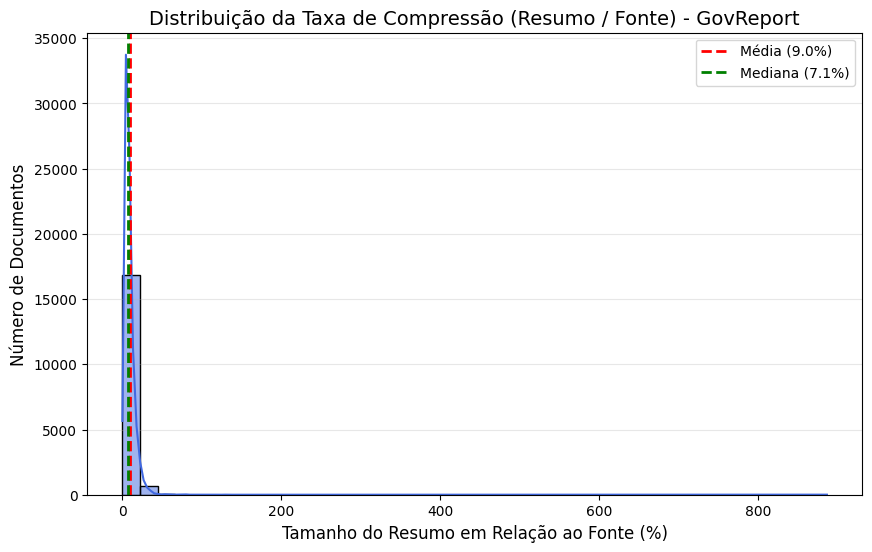

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm import tqdm
import logging

# Ocultar os avisos chatos de "tamanho máximo excedido" do tokenizador
logging.getLogger("transformers.tokenization_utils_base").setLevel(logging.ERROR)

# =========================
# CONFIGURAÇÕES
# =========================
model_name = "google-t5/t5-base"
dataset_name = "ccdv/govreport-summarization"
split_name = "train"
num_amostras = 17500  # Analisar 500 documentos já dá uma excelente significância estatística

print("Carregando tokenizador...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Carregando dataset...")
dataset = load_dataset(dataset_name, split=split_name)

# Listas para armazenar os resultados
source_lengths = []
summary_lengths = []
compression_ratios = []

# =========================
# ANÁLISE DOS TOKENS
# =========================
print(f"\nAnalisando {num_amostras} pares de documento-resumo...")

# Usamos itertools ou fatiamento para pegar apenas a quantidade desejada
for item in tqdm(dataset.select(range(num_amostras))):
    texto_fonte = item["report"]
    resumo_referencia = item["summary"]

    # Tokeniza sem truncar para contar o tamanho REAL do texto
    tokens_fonte = len(tokenizer.encode(texto_fonte, truncation=False))
    tokens_resumo = len(tokenizer.encode(resumo_referencia, truncation=False))

    # Prevenção contra divisão por zero
    if tokens_fonte > 0:
        razao = (tokens_resumo / tokens_fonte) * 100

        source_lengths.append(tokens_fonte)
        summary_lengths.append(tokens_resumo)
        compression_ratios.append(razao)

# =========================
# ESTATÍSTICAS FINAIS
# =========================
media_fonte = np.mean(source_lengths)
media_resumo = np.mean(summary_lengths)
media_razao = np.mean(compression_ratios)
mediana_razao = np.median(compression_ratios)

print("\n" + "="*40)
print("📊 RESULTADOS DA ANÁLISE DE TOKENS")
print("="*40)
print(f"Média de Tokens no Documento Fonte : {media_fonte:.0f} tokens")
print(f"Média de Tokens no Resumo (Dataset): {media_resumo:.0f} tokens")
print(f"Taxa de Compressão Média         : {media_razao:.2f}% do texto original")
print(f"Taxa de Compressão Mediana       : {mediana_razao:.2f}% do texto original")
print(f"Maior Resumo Encontrado (em %)     : {np.max(compression_ratios):.2f}%")
print(f"Menor Resumo Encontrado (em %)     : {np.min(compression_ratios):.2f}%")
print("="*40)

# =========================
# GERAÇÃO DO GRÁFICO (Para a Dissertação)
# =========================
plt.figure(figsize=(10, 6))
sns.histplot(compression_ratios, bins=40, kde=True, color="royalblue")

plt.axvline(media_razao, color='red', linestyle='dashed', linewidth=2, label=f'Média ({media_razao:.1f}%)')
plt.axvline(mediana_razao, color='green', linestyle='dashed', linewidth=2, label=f'Mediana ({mediana_razao:.1f}%)')

plt.title("Distribuição da Taxa de Compressão (Resumo / Fonte) - GovReport", fontsize=14)
plt.xlabel("Tamanho do Resumo em Relação ao Fonte (%)", fontsize=12)
plt.ylabel("Número de Documentos", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Salvar o gráfico em alta resolução para usar no seu texto
plt.savefig("taxa_compressao_govreport.png", dpi=300, bbox_inches='tight')
print("\nGráfico salvo como 'taxa_compressao_govreport.png'!")
plt.show()

In [ ]:
!git clone https://github.com/cassiomatheus/FENICE.git

Cloning into 'FENICE'...
remote: Enumerating objects: 429, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (197/197), done.
remote: Total 429 (delta 99), reused 178 (delta 39), pack-reused 188 (from 1)
Receiving objects: 100% (429/429), 16.62 MiB | 15.65 MiB/s, done.
Resolving deltas: 100% (200/200), done.


In [ ]:
cd /content/FENICE

/content/FENICE


In [ ]:
!git checkout reducao

Branch 'reducao' set up to track remote branch 'reducao' from 'origin'.
Switched to a new branch 'reducao'


In [ ]:
!git branch

  master
* reducao


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 19.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 41.4 MB/s eta 0:00:00
   ━━

In [ ]:
import sys
sys.path.append("/content/FENICE")
from metric.FENICE import FENICE
from metric.utils.utils import compute_source_usage_chunks, evaluate_sample


#from metric.FENICE import FENICE
fenice = FENICE(
    doc_level_nli=True,
)

document = """
        Natural Language Processing (NLP) began in the 1950s, heavily influenced by Noam Chomsky's linguistic theories and rigid rule-based systems. One of the first milestones was the ELIZA program, developed in the 1960s, which simulated a psychotherapist using pattern matching and word substitution, with no real understanding of the text. These early systems were limited and required humans to manually program thousands of grammatical rules.

        During the late 1980s and 1990s, NLP underwent a statistical revolution. With the increase in computational power, researchers abandoned manual rules and started using machine learning algorithms, such as Hidden Markov Models (HMM) and Support Vector Machines (SVM). This transition allowed computers to learn patterns directly from large volumes of text data. In the 2000s, Recurrent Neural Networks (RNNs) began to gain prominence, allowing the processing of sequences, although they suffered from the forgetting of information in very long texts.

        The landscape changed definitively in 2017 with the publication of the paper "Attention Is All You Need", which introduced the Transformer architecture. By discarding recurrence in favor of a parallel self-attention mechanism, Transformers enabled the training of Large Language Models (LLMs). This architecture solved the sequential processing bottleneck and gave rise to powerful modern models, drastically improving tasks like translation and the summarization of long documents.
    """

summary = """
        Natural language processing started with rule-based systems and gained prominence with the ELIZA model, which possessed 5 million neural parameters. In the following decades, there was a transition to statistical methods and machine learning models, which could extract patterns from textual data. Finally, the field was revolutionized in 1998 with the introduction of the Transformer architecture, which allowed the creation of modern LLMs and optimized the summarization of extensive documents.
    """

batch = [
    {"document": document, "summary": summary}
]

results = fenice.score_batch(batch)
print(results)

print("\nNova funcionalidade (chunk-based source usage)")

sample_result = results[0]

usage_stats = compute_source_usage_chunks(
    alignments=sample_result["alignments"],
    document=batch[0]["document"]
)

# from pprint import pprint
# pprint(sample_result["alignments"][0])
round(usage_stats["region_ratios"]["start"], 4)

print(f"Inicio: {round(usage_stats["region_ratios"]["start"], 4)}")
print(f"Meio: {round(usage_stats["region_ratios"]["middle"], 4)}")
print(f"Fim: {round(usage_stats["region_ratios"]["end"], 4)}")


print("Claims por região:", usage_stats["region_counts"])
print("Proporção de claims:", usage_stats["region_ratios"])
print("Cobertura textual:", usage_stats["coverage_ratio"])
print("Mean position:", round(usage_stats["mean_position"], 4))

metrics = evaluate_sample(fenice, document, summary)

print(metrics)
print(metrics["evidence_score"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Computing FENICE...: 100%|██████████| 1/1 [00:00<00:00, 29.95it/s]


[{'score': 0.7219472378492355, 'status_counts': {'supported': 6, 'contradicted': 2, 'not_supported': 0}, 'status_ratios': {'supported': 0.75, 'contradicted': 0.25, 'not_supported': 0.0}, 'error_type_counts': {'entity': 1, 'predicate': 2, 'coreference': 0, 'other': 0}, 'error_type_ratios': {'entity': 0.5, 'predicate': 1.0, 'coreference': 0.0, 'other': 0.0}, 'alignments': [{'score': 0.9992413520812988, 'probs': [0.99951171875, 0.00019752979278564453, 0.0002703666687011719], 'summary_claim': 'Natural language processing started with rule-based systems.', 'source_passage': 'DOCUMENT_CHUNK', 'all_alignments': [{'score': 0.962554931640625, 'probs': [0.98046875, 0.0014095306396484375, 0.017913818359375], 'summary_claim': 'Natural language processing started with rule-based systems.', 'source_passage': "\n        Natural Language Processing (NLP) began in the 1950s, heavily influenced by Noam Chomsky's linguistic theories and rigid rule-based systems."}, None, {'score': 0.9992320537567139, 'pr

splitting document batches into sentences: 100%|██████████| 1/1 [00:00<00:00, 47.92it/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
splitting document batches into sentences: 100%|██████████| 1/1 [00:00<00:00, 53.42it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
splitting document batches into sentences: 100%|██████████| 1/1 [00:00<00:00, 50.63it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
splitting document batches into sentences: 100%|██████████| 1/1 [00:00<00:00, 44.75it/s]
Special

{'evidence_score': 0.3729053530842066, 'faithfulness_score': 0.25, 'stability_score': 0.9603624270037208, 'reliability_score': 0.5122708693347988}
0.3729053530842066


In [ ]:
!cd /content/FENICE

In [ ]:
import sys
import torch

sys.path.append("/content/FENICE")
from metric.FENICE import FENICE

#from metric.FENICE import FENICE
fenice = FENICE()

document = """
Launched on April 24, 1990, aboard the Space Shuttle Discovery on mission STS-31, the Hubble Space Telescope (HST) marked the beginning of a revolution in modern astronomy. A fruit of a decades-long collaboration between NASA and the European Space Agency (ESA), the observatory was named in honor of astronomer Edwin Hubble, who proved that the universe extends far beyond our own galaxy.

However, the beginning of the mission was marked by a devastating failure. A few weeks after entering orbit, the first images sent back to Earth proved to be unexpectedly blurry. Data analysis showed that the 2.4-meter primary mirror, manufactured by the company Perkin-Elmer, had been polished to the wrong shape at the edges. The error was tiny—about 2.2 micrometers, or one-fiftieth the thickness of a human hair—but sufficient to cause severe spherical aberration, preventing the telescope from focusing light accurately. NASA was harshly criticized by the media and the US Congress.

The solution came three years later, in December 1993, with the first servicing mission (SM1). Seven astronauts aboard the Space Shuttle Endeavour performed five record-breaking spacewalks to install COSTAR (Corrective Optics Space Telescope Axial Replacement). This device acted like 'eyeglasses' for Hubble, correcting the light distortion before it reached the scientific instruments. After the repair, Hubble's vision became crystal clear, allowing for unprecedented observations.

Over more than 30 years, Hubble has performed fundamental measurements. It helped refine the age of the universe to about 13.8 billion years and played a crucial role in the discovery of 'Dark Energy,' a mysterious force that is accelerating the expansion of the cosmos. Additionally, the telescope analyzed the atmospheres of exoplanets, detecting the presence of sodium and other elements. Lyman Spitzer, the theoretical physicist who proposed the idea of a space telescope in the 1940s, did not live to see all these discoveries, but his concept proved visionary.

While Hubble observes visible and ultraviolet light, its successor, the James Webb Space Telescope (JWST), launched in 2021, focuses on the infrared spectrum. Unlike Hubble, which orbits Earth at an altitude of 540 km, Webb is positioned at the Lagrange Point L2, 1.5 million kilometers away.
"""

summary = """
The Hubble Space Telescope, a partnership between NASA and ESA, was launched in 1990 to revolutionize astronomy.

Immediately after launch, the images returned by the telescope were perfectly sharp, confirming the absolute precision of the primary mirror.

The observatory was carried into orbit by the Space Shuttle Atlantis during mission STS-31.

NASA deliberately ignored the mirror defect and decided never to send a repair mission to fix it.

Physicist Lyman Spitzer personally performed the spacewalks in 1993 to install the COSTAR device.

Furthermore, Hubble detected clear signals of advanced civilizations in the Andromeda galaxy.
"""

# Crie o batch para o FENICE
batch = [{"document": document, "summary": summary}]

results = fenice.score_batch(batch)
print("\n",results)


# print(f"VRAM utilizada{fenice.vram_stats}")




torch.cuda.reset_peak_memory_stats()

max_vram_mb = torch.cuda.max_memory_allocated() / 1024**2

print(f"VRAM máxima utilizada: {max_vram_mb:.2f} MB")




Computing FENICE...: 100%|██████████| 1/1 [00:00<00:00,  6.03it/s]



 [{'score': 0.24271462857723236, 'status_counts': {'supported': 2, 'contradicted': 6, 'not_supported': 0}, 'status_ratios': {'supported': 0.25, 'contradicted': 0.75, 'not_supported': 0.0}, 'error_type_counts': {'entity': 3, 'predicate': 6, 'coreference': 0, 'other': 0}, 'error_type_ratios': {'entity': 0.5, 'predicate': 1.0, 'coreference': 0.0, 'other': 0.0}, 'alignments': [{'score': 0.9992406368255615, 'probs': [0.99951171875, 0.0002601146697998047, 0.00027108192443847656], 'summary_claim': 'The Hubble Space Telescope was launched in 1990 to revolutionize astronomy.', 'source_passage': '\nLaunched on April 24, 1990, aboard the Space Shuttle Discovery on mission STS-31, the Hubble Space Telescope (HST) marked the beginning of a revolution in modern astronomy. A fruit of a decades-long collaboration between NASA and the European Space Agency (ESA), the observatory was named in honor of astronomer Edwin Hubble, who proved that the universe extends far beyond our own galaxy.\n\n However, 

#Dataset

In [ ]:
from transformers import AutoTokenizer
import pandas as pd
from datasets import load_dataset

# Carrega dataset
ds = load_dataset("ccdv/govreport-summarization")
df = pd.DataFrame(ds["test"])

#print(df)

# Exemplo com tokenizer do BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

df['ref_len_tokens'] = df['report'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=False)))
df['summary_len_tokens'] = df['summary'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=False)))

#print(df[['ref_len_tokens','summary_len_tokens']].head())

print(df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

document/train-00000-of-00002.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

document/train-00001-of-00002.parquet:   0%|          | 0.00/229M [00:00<?, ?B/s]

document/validation-00000-of-00001.parqu(…):   0%|          | 0.00/26.1M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (11706 > 512). Running this sequence through the model will result in indexing errors


                                                report  \
0    In our prior work, we have found that technolo...   
1    A variety of federal laws, regulations, and po...   
2    According to the National Research Council, al...   
3    Nursing homes are required to keep residents s...   
4    This section provides an overview of (1) the l...   
..                                                 ...   
968  This report is an overview of U.S. foreign ass...   
969  Congress directs the U.S. Environmental Protec...   
970  Coal mining and production in the United State...   
971  C ongressional employees are retained to perfo...   
972  Congress annually considers 12 regular appropr...   

                                               summary  ref_len_tokens  \
0    Multiple firms have produced cell-cultured mea...           11706   
1    Federal advisory committees provide advice to ...           11162   
2    DOD manages a global real-estate portfolio wit...           11594   
3    Nu

In [ ]:
print(len(df[df['ref_len_tokens'] < 1500]))
# Exibir a segunda linha (índice 1, já que Python é zero-indexed)
print(df.iloc[711]["summary"])

df[(df['ref_len_tokens'] > 600) & (df['ref_len_tokens'] < 1500)]

5
The Department of Energy's (DOE's) nonproliferation and national security programs provide technical capabilities to support U.S. efforts to "prevent, counter, respond" to the proliferation of nuclear weapons worldwide, including by both states and non-state actors. These programs are administered by the National Nuclear Security Administration (NNSA), a semi-autonomous agency established within DOE in 2000. NNSA is responsible for maintaining the U.S. nuclear weapons stockpile, providing nuclear fuel to the Navy, nuclear and radiological emergency response, and nonproliferation. NNSA recently reorganized the Office of Defense Nuclear Nonproliferation, which is funded under the Defense Nuclear Nonproliferation (DNN) account. This report addresses the programs in the NNSA's DNN account, appropriated by the Energy and Water appropriations bill. The FY2020 Consolidated Appropriations bill ( P.L. 116-94) funded the NNSA DNN accounts at $2.164 billion. The FY2021 request for DNN appropria

,report,summary,ref_len_tokens,summary_len_tokens
695,The Elementary and Secondary Education Act (ES...,The Elementary and Secondary Education Act (ES...,1271,305
711,The Defense Nuclear Nonproliferation (DNN) pro...,The Department of Energy's (DOE's) nonprolifer...,1225,308
836,"R ecently, the Federal Bureau of Investigation...",As federal agencies adjust their operations in...,1373,242
971,C ongressional employees are retained to perfo...,"The roles, duties, and activities of congressi...",1209,406


In [ ]:
print(df.iloc[695]["report"])

The Elementary and Secondary Education Act (ESEA), most recently comprehensively amended by the Every Student Succeeds Act (ESSA; P.L. 114-95 ), is the primary source of federal aid to elementary and secondary education. Title I-A is the largest program in the ESEA, funded at $15.9 billion for FY2019. Title I-A is designed to provide supplementary educational and related services to low-achieving and other students attending elementary and secondary schools with relatively high concentrations of students from low-income families. The U.S. Department of Education (ED) determines Title I-A grants to local educational agencies (LEAs) based on four separate funding formulas: Basic Grants, Concentration Grants, Targeted Grants, and Education Finance Incentive Grants (EFIG). This report provides FY2019 state grant amounts under each of the four formulas used to determine Title I-A grants. For a general overview of the Title I-A formulas, see CRS Report R44164, ESEA Title I-A Formulas: In Bri

### Teste new

In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("ccdv/govreport-summarization")

ds_test_10 = ds["test"].select(range(20))

df = pd.DataFrame(ds_test_10)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

df['ref_len_tokens'] = df['report'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=False))
)

df['summary_len_tokens'] = df['summary'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=False))
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (11706 > 512). Running this sequence through the model will result in indexing errors


In [ ]:
def df_to_fenice_batches(df, batch_size=1):
    batch = []
    for _, row in df.iterrows():
        batch.append({
            "document": row["report"],
            "summary": row["summary"]
        })
        if len(batch) == batch_size:
            yield batch
            batch = []
    if batch:
        yield batch


In [ ]:
cd FENICE/

/content/FENICE


In [ ]:
import sys
sys.path.append("/content/FENICE")
from metric.FENICE import FENICE
from metric.utils.source_usage import analyze_source_usage, compute_source_usage_chunks, cleanup_cuda

#from metric.FENICE import FENICE
fenice = FENICE(
    use_coref=True,
    paragraph_level_nli=True,
    doc_level_nli=True,
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Dispositivo selecionado: cuda


In [ ]:
results = []

for i, batch in enumerate(df_to_fenice_batches(df, batch_size=1)):
    print(f"Processing document {i}")

    fenice_out = fenice.score_batch(batch)[0]

    # source_stats = analyze_source_usage(
    #     document=batch[0]["document"],
    #     alignments=fenice_out["alignments"]
    # )

    # sample_result = results[0]

    usage_stats = compute_source_usage_chunks(
        alignments=fenice_out["alignments"],
        document=batch[0]["document"]
    )

    results.append({
        "sample_id": i,
        "score": round(fenice_out["score"], 5),
        "supported": fenice_out["status_counts"]["supported"],
        "contradicted": fenice_out["status_counts"]["contradicted"],
        "not_supported": fenice_out["status_counts"]["not_supported"],
        "predicate_errors": fenice_out["error_type_counts"]["predicate"],
        "entity_errors": fenice_out["error_type_counts"]["entity"],
        "coref_errors": fenice_out["error_type_counts"]["coreference"],
        "other_erros": fenice_out["error_type_counts"]["other"],

        #Testar aqui
        "coverage_ratio": round(usage_stats["coverage_ratio"], 5),
        "mean_position": round(usage_stats["mean_position"], 5),

        # 🔹 NOVAS COLUNAS (positional usage)
        "start_ratio": round(usage_stats["region_ratios"]["start"], 5),
        "middle_ratio": round(usage_stats["region_ratios"]["middle"], 5),
        "end_ratio": round(usage_stats["region_ratios"]["end"], 5),

        #"positions": usage_stats["positions"],
        #"used_chunk_indices": usage_stats["used_chunk_indices"],
        #"unused_chunk_indices": usage_stats["unused_chunk_indices"],



        # "start_ratio": source_stats["region_ratios"]["start"],
        # "middle_ratio": source_stats["region_ratios"]["middle"],
        # "end_ratio": source_stats["region_ratios"]["end"],

        "ref_len_tokens": df.loc[i, "ref_len_tokens"],
        "summary_len_tokens": df.loc[i, "summary_len_tokens"],
    })


    cleanup_cuda()


results_df = pd.DataFrame(results)
#results_df.to_csv("/content/fenice_govreport_full.csv", index=False)
results_df.to_excel("/content/fenice_govreport_full.xlsx", index=False)

Processing document 0


Executing coreference resolution:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Computing FENICE...: 100%|██████████| 1/1 [00:00<00:00, 29.44it/s]


Processing document 1


...

Computing FENICE...: 100%|██████████| 1/1 [00:00<00:00, 33.79it/s]


Processing document 15


Executing coreference resolution:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Computing alignments...:  88%|████████▊ | 7/8 [00:14<00:02,  2.35s/it]

#Sumarização Abstrativa

##Sumarização por prompt

In [ ]:
!pip install transformers

In [ ]:
! pip install sentencepiece

In [ ]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

In [ ]:
tokenizer = T5Tokenizer.from_pretrained('t5-large')
model = T5ForConditionalGeneration.from_pretrained('t5-large', return_dict=True)

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
sequence = ("The series focuses on Monkey D. Luffy, a young man made of rubber, who, inspired by his childhood idol,"
             "the powerful pirate Red-Haired Shanks, sets off on a journey from the East Blue Sea to find the mythical treasure,"
             "the One Piece, and proclaim himself the King of the Pirates. In an effort to organize his own crew, the Straw Hat Pirates,"
             "Luffy rescues and befriends a pirate hunter and swordsman named Roronoa Zoro, and they head off in search of the "
             "titular treasure. They are joined in their journey by Nami, a money-obsessed thief and navigator; Usopp, a sniper "
             "and compulsive liar; and Sanji, a perverted but chivalrous cook. They acquire a ship, the Going Merry, and engage in confrontations"
             "with notorious pirates of the East Blue. As Luffy and his crew set out on their adventures, others join the crew later in the series, "
             "including Tony Tony Chopper, an anthropomorphized reindeer doctor; Nico Robin, an archaeologist and former Baroque Works assassin; "
             "Franky, a cyborg shipwright; Brook, a skeleton musician and swordsman; and Jimbei, a fish-man helmsman and former member of the Seven "
             "Warlords of the Sea. Once the Going Merry is damaged beyond repair, Franky builds the Straw Hat Pirates a new ship, the Thousand Sunny,"
             "Together, they encounter other pirates, bounty hunters, criminal organizations, revolutionaries, secret agents, and soldiers of the"
             "corrupt World Government, and various other friends and foes, as they sail the seas in pursuit of their dreams.")

In [ ]:
sequence = df.iloc[695]["report"]

In [ ]:
print(sequence)

The Elementary and Secondary Education Act (ESEA), most recently comprehensively amended by the Every Student Succeeds Act (ESSA; P.L. 114-95 ), is the primary source of federal aid to elementary and secondary education. Title I-A is the largest program in the ESEA, funded at $15.9 billion for FY2019. Title I-A is designed to provide supplementary educational and related services to low-achieving and other students attending elementary and secondary schools with relatively high concentrations of students from low-income families. The U.S. Department of Education (ED) determines Title I-A grants to local educational agencies (LEAs) based on four separate funding formulas: Basic Grants, Concentration Grants, Targeted Grants, and Education Finance Incentive Grants (EFIG). This report provides FY2019 state grant amounts under each of the four formulas used to determine Title I-A grants. For a general overview of the Title I-A formulas, see CRS Report R44164, ESEA Title I-A Formulas: In Bri

In [ ]:
inputs = tokenizer.encode("summarize: " + sequence,
                          return_tensors='pt',
                          max_length=512,
                          truncation=True)

In [ ]:
summarization_ids = model.generate(inputs, max_length=80, min_length=40, length_penalty=5., num_beams=2)

In [ ]:
summarization = tokenizer.decode(summarization_ids[0])

In [ ]:
summarization

'<pad> this report provides FY2019 state grant amounts under each of the four formulas . Title I-A is the largest program in the ESEA, funded at $15.9 billion for FY2019 . funds are allocated to LEAs via state educational agencies (SEAs)</s>'

In [ ]:
import sys
sys.path.append("/content/FENICE")
from metric.FENICE import FENICE

#from metric.FENICE import FENICE
fenice = FENICE()


document = sequence

summary = summarization

batch = [
    {"document": document, "summary": summary}
]

results = fenice.score_batch(batch)
print(results)


splitting document batches into sentences: 100%|██████████| 1/1 [00:00<00:00,  6.19it/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/164 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Computing FENICE...: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]

[{'score': 0.9993936977880367, 'alignments': [{'score': 0.9990499863633886, 'summary_claim': 'This report provides FY2019 state grant amounts under each of the four formulas.', 'source_passage': "The percentage share of funds allocated under each of the Title I-A formulas was calculated by CRS for each state by dividing the total grant received by the total amount allocated under each respective formula. Table 1 provides each state's grant amount and percentage share of funds allocated under each of the Title I-A formulas for FY2019. Total Title I-A grants, calculated by summing the state level grant for each of the four formulas, are also shown in Table 1 . Overall, California received the largest total Title I-A grant amount ($2.0 billion) and, as a result, the largest percentage share (12.52%) of Title I-A grants. Vermont received the smallest total Title I-A grant amount ($36.9 million) and, as a result, the smallest percentage share (0.24%) of Title I-A grants."}, {'score': 0.9996

##Sumarização pelo HugginFace

In [ ]:
!pip install transformers

###Modelo Pegasus-x-large
- max_position_embeddings = 16384
- vocab_size = 96103

In [ ]:
import torch
from transformers import pipeline

summarizer = pipeline(
    task="summarization",
    model="google/pegasus-x-large",
    #dtype=torch.bfloat16,
    device=0,
    tokenizer="google/pegasus-x-large",
)

ARTICLE = df.iloc[695]["report"]

sumario = summarizer(ARTICLE, max_length=500, min_length=30, do_sample=False)

sum = sumario[0]["summary_text"]
print(sum)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/262 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1227 > 1024). Running this sequence through the model will result in indexing errors


For example, Alaska, Arizona, California, Delaware, the District of Columbia, Florida, Georgia, Hawaii, Illinois, Louisiana, Maine, Maryland, Montana, Nevada, New Hampshire, New Mexico, New York, North Dakota, Rhode Island, South Dakota, Texas, Vermont, and Wyoming each received a higher percentage share of Targeted Grants than of overall Title I-A funds, indicating that the Targeted Grant formula is more favorable to them than other Title I-A formulas may be.


In [ ]:
import torch
from transformers import pipeline

pipeline = pipeline(
    task="summarization",
    model="google/pegasus-x-large",
    #dtype=torch.bfloat16,
    device=0
)

art = df.iloc[695]["report"]

sum = pipeline(art)

print(sum[0]["summary_text"])


Token indices sequence length is longer than the specified maximum sequence length for this model (1227 > 1024). Running this sequence through the model will result in indexing errors
Your max_length is set to 16384, but your input_length is only 1227. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=613)


For example, Alaska, Arizona, California, Delaware, the District of Columbia, Florida, Georgia, Hawaii, Illinois, Louisiana, Maine, Maryland, Montana, Nevada, New Hampshire, New Mexico, New York, North Dakota, Rhode Island, South Dakota, Texas, Vermont, and Wyoming each received a higher percentage share of Targeted Grants than of overall Title I-A funds, indicating that the Targeted Grant formula is more favorable to them than other Title I-A formulas may be.


In [ ]:
import sys
sys.path.append("/content/FENICE")
from metric.FENICE import FENICE

#from metric.FENICE import FENICE
fenice = FENICE()


document = ARTICLE

summary = sum

batch = [
    {"document": document, "summary": summary}
]

results = fenice.score_batch(batch)
print(results)


splitting document batches into sentences: 100%|██████████| 1/1 [00:00<00:00, 12.40it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Computing FENICE...: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s]

[{'score': 0.9423148753121495, 'alignments': [{'score': 0.9564321488142014, 'summary_claim': 'Alaska, Arizona, California, Delaware, the District of Columbia, Florida, Georgia, Hawaii, Illinois, Louisiana, Maine, Maryland, Montana, Nevada, New Hampshire, New Mexico, New York, North Dakota, Rhode Island, South Dakota, Texas, Vermont, and Wyoming each received a higher percentage share of Targeted Grants than of overall Title I-A funds.', 'source_passage': 'DOCUMENT'}, {'score': 0.9281976018100977, 'summary_claim': 'The Targeted Grant formula is more favorable to Alaska, Arizona, California, Delaware, the District of Columbia, Florida, Georgia, Hawaii, Illinois, Louisiana, Maine, Maryland, Montana, Nevada, New Hampshire, New Mexico, New York, North Dakota, Rhode Island, South Dakota, Texas, Vermont, and Wyoming.', 'source_passage': 'DOCUMENT'}]}]


###Modelo BART (facebook)
- vocab_size = 50265
- max_position_embeddings = 1024

In [ ]:
import torch
from transformers import pipeline

summarizer = pipeline(
    task="summarization",
    model="facebook/bart-large",
    dtype=torch.bfloat16,
    device_map=0,
)

ARTICLE = """
Hugging Face: Revolutionizing Natural Language Processing
Introduction
In the rapidly evolving field of Natural Language Processing (NLP), Hugging Face has emerged as a prominent and innovative force. This article will explore the story and significance of Hugging Face, a company that has made remarkable contributions to NLP and AI as a whole. From its inception to its role in democratizing AI, Hugging Face has left an indelible mark on the industry.
The Birth of Hugging Face
Hugging Face was founded in 2016 by Clément Delangue, Julien Chaumond, and Thomas Wolf. The name "Hugging Face" was chosen to reflect the company's mission of making AI models more accessible and friendly to humans, much like a comforting hug. Initially, they began as a chatbot company but later shifted their focus to NLP, driven by their belief in the transformative potential of this technology.
Transformative Innovations
Hugging Face is best known for its open-source contributions, particularly the "Transformers" library. This library has become the de facto standard for NLP and enables researchers, developers, and organizations to easily access and utilize state-of-the-art pre-trained language models, such as BERT, GPT-3, and more. These models have countless applications, from chatbots and virtual assistants to language translation and sentiment analysis.
Key Contributions:
1. **Transformers Library:** The Transformers library provides a unified interface for more than 50 pre-trained models, simplifying the development of NLP applications. It allows users to fine-tune these models for specific tasks, making it accessible to a wider audience.
2. **Model Hub:** Hugging Face's Model Hub is a treasure trove of pre-trained models, making it simple for anyone to access, experiment with, and fine-tune models. Researchers and developers around the world can collaborate and share their models through this platform.
3. **Hugging Face Transformers Community:** Hugging Face has fostered a vibrant online community where developers, researchers, and AI enthusiasts can share their knowledge, code, and insights. This collaborative spirit has accelerated the growth of NLP.
Democratizing AI
Hugging Face's most significant impact has been the democratization of AI and NLP. Their commitment to open-source development has made powerful AI models accessible to individuals, startups, and established organizations. This approach contrasts with the traditional proprietary AI model market, which often limits access to those with substantial resources.
By providing open-source models and tools, Hugging Face has empowered a diverse array of users to innovate and create their own NLP applications. This shift has fostered inclusivity, allowing a broader range of voices to contribute to AI research and development.
Industry Adoption
The success and impact of Hugging Face are evident in its widespread adoption. Numerous companies and institutions, from startups to tech giants, leverage Hugging Face's technology for their AI applications. This includes industries as varied as healthcare, finance, and entertainment, showcasing the versatility of NLP and Hugging Face's contributions.
Future Directions
Hugging Face's journey is far from over. As of my last knowledge update in September 2021, the company was actively pursuing research into ethical AI, bias reduction in models, and more. Given their track record of innovation and commitment to the AI community, it is likely that they will continue to lead in ethical AI development and promote responsible use of NLP technologies.
Conclusion
Hugging Face's story is one of transformation, collaboration, and empowerment. Their open-source contributions have reshaped the NLP landscape and democratized access to AI. As they continue to push the boundaries of AI research, we can expect Hugging Face to remain at the forefront of innovation, contributing to a more inclusive and ethical AI future. Their journey reminds us that the power of open-source collaboration can lead to groundbreaking advancements in technology and bring AI within the reach of many.
"""
print(summarizer(ARTICLE, max_length=1000, min_length=30, do_sample=False))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Your max_length is set to 1000, but your input_length is only 820. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=410)
Both `max_new_tokens` (=256) and `max_length`(=1000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'summary_text': 'Huangging Face: Revolutionizing Natural Language Processing (NLP) and AI as a whole. This article will explore the story and significance of Hugging Face, a company that has emerged as a prominent and innovative force. Their open-source contributions have reshaped the NLP landscape and democratized access to AI. Their journey reminds us that the power of openness and collaboration can lead to groundbreaking advancements in technology and bring AI within the reach of many. From its inception to its role in democratizing AI, Hugging face has left an indelible mark on the industry. The name "Hugging Face" was chosen to reflect the company\'s mission of making AI models more accessible and friendly to humans, much like a comforting hug. It allows users to fine-tune these models for specific tasks, making it accessible to a wider audience. This approach contrasts with the traditional proprietary AI model market, which often limits access to those with substantial resource

###Modelo Falconsai(Fine-Tuned T5 Small)
- vocab_size =  32128
- janela de contexto = 512

In [ ]:
from transformers import pipeline

summarizer = pipeline("summarization", model="Falconsai/text_summarization")

ARTICLE = """
Hugging Face: Revolutionizing Natural Language Processing
Introduction
In the rapidly evolving field of Natural Language Processing (NLP), Hugging Face has emerged as a prominent and innovative force. This article will explore the story and significance of Hugging Face, a company that has made remarkable contributions to NLP and AI as a whole. From its inception to its role in democratizing AI, Hugging Face has left an indelible mark on the industry.
The Birth of Hugging Face
Hugging Face was founded in 2016 by Clément Delangue, Julien Chaumond, and Thomas Wolf. The name "Hugging Face" was chosen to reflect the company's mission of making AI models more accessible and friendly to humans, much like a comforting hug. Initially, they began as a chatbot company but later shifted their focus to NLP, driven by their belief in the transformative potential of this technology.
Transformative Innovations
Hugging Face is best known for its open-source contributions, particularly the "Transformers" library. This library has become the de facto standard for NLP and enables researchers, developers, and organizations to easily access and utilize state-of-the-art pre-trained language models, such as BERT, GPT-3, and more. These models have countless applications, from chatbots and virtual assistants to language translation and sentiment analysis.
Key Contributions:
1. **Transformers Library:** The Transformers library provides a unified interface for more than 50 pre-trained models, simplifying the development of NLP applications. It allows users to fine-tune these models for specific tasks, making it accessible to a wider audience.
2. **Model Hub:** Hugging Face's Model Hub is a treasure trove of pre-trained models, making it simple for anyone to access, experiment with, and fine-tune models. Researchers and developers around the world can collaborate and share their models through this platform.
3. **Hugging Face Transformers Community:** Hugging Face has fostered a vibrant online community where developers, researchers, and AI enthusiasts can share their knowledge, code, and insights. This collaborative spirit has accelerated the growth of NLP.
Democratizing AI
Hugging Face's most significant impact has been the democratization of AI and NLP. Their commitment to open-source development has made powerful AI models accessible to individuals, startups, and established organizations. This approach contrasts with the traditional proprietary AI model market, which often limits access to those with substantial resources.
By providing open-source models and tools, Hugging Face has empowered a diverse array of users to innovate and create their own NLP applications. This shift has fostered inclusivity, allowing a broader range of voices to contribute to AI research and development.
Industry Adoption
The success and impact of Hugging Face are evident in its widespread adoption. Numerous companies and institutions, from startups to tech giants, leverage Hugging Face's technology for their AI applications. This includes industries as varied as healthcare, finance, and entertainment, showcasing the versatility of NLP and Hugging Face's contributions.
Future Directions
Hugging Face's journey is far from over. As of my last knowledge update in September 2021, the company was actively pursuing research into ethical AI, bias reduction in models, and more. Given their track record of innovation and commitment to the AI community, it is likely that they will continue to lead in ethical AI development and promote responsible use of NLP technologies.
Conclusion
Hugging Face's story is one of transformation, collaboration, and empowerment. Their open-source contributions have reshaped the NLP landscape and democratized access to AI. As they continue to push the boundaries of AI research, we can expect Hugging Face to remain at the forefront of innovation, contributing to a more inclusive and ethical AI future. Their journey reminds us that the power of open-source collaboration can lead to groundbreaking advancements in technology and bring AI within the reach of many.
"""
print(summarizer(ARTICLE, max_length=1000, min_length=30, do_sample=False))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0
Token indices sequence length is longer than the specified maximum sequence length for this model (851 > 512). Running this sequence through the model will result in indexing errors
Your max_length is set to 1000, but your input_length is only 851. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=425)
Both `max_new_tokens` (

[{'summary_text': 'Hugging Face has emerged as a prominent and innovative force in NLP . From its inception to its role in democratizing AI, the company has left an indelible mark on the industry . The name "Hugging Face" was chosen to reflect the company\'s mission of making AI models more accessible and friendly to humans .'}]


###Modelo Mistral
- vocab_size = 32000
- max_position_embeddings = 131072

Obs: Estourou o consumo de GPU

In [ ]:
import torch
from transformers import pipeline

summarizer = pipeline(
    task="summarization",
    model="mistralai/Mistral-7B-Instruct-v0.3",
    dtype=torch.bfloat16,
    device_map=0,
)

ARTICLE = """
Hugging Face: Revolutionizing Natural Language Processing
Introduction
In the rapidly evolving field of Natural Language Processing (NLP), Hugging Face has emerged as a prominent and innovative force. This article will explore the story and significance of Hugging Face, a company that has made remarkable contributions to NLP and AI as a whole. From its inception to its role in democratizing AI, Hugging Face has left an indelible mark on the industry.
The Birth of Hugging Face
Hugging Face was founded in 2016 by Clément Delangue, Julien Chaumond, and Thomas Wolf. The name "Hugging Face" was chosen to reflect the company's mission of making AI models more accessible and friendly to humans, much like a comforting hug. Initially, they began as a chatbot company but later shifted their focus to NLP, driven by their belief in the transformative potential of this technology.
Transformative Innovations
Hugging Face is best known for its open-source contributions, particularly the "Transformers" library. This library has become the de facto standard for NLP and enables researchers, developers, and organizations to easily access and utilize state-of-the-art pre-trained language models, such as BERT, GPT-3, and more. These models have countless applications, from chatbots and virtual assistants to language translation and sentiment analysis.
Key Contributions:
1. **Transformers Library:** The Transformers library provides a unified interface for more than 50 pre-trained models, simplifying the development of NLP applications. It allows users to fine-tune these models for specific tasks, making it accessible to a wider audience.
2. **Model Hub:** Hugging Face's Model Hub is a treasure trove of pre-trained models, making it simple for anyone to access, experiment with, and fine-tune models. Researchers and developers around the world can collaborate and share their models through this platform.
3. **Hugging Face Transformers Community:** Hugging Face has fostered a vibrant online community where developers, researchers, and AI enthusiasts can share their knowledge, code, and insights. This collaborative spirit has accelerated the growth of NLP.
Democratizing AI
Hugging Face's most significant impact has been the democratization of AI and NLP. Their commitment to open-source development has made powerful AI models accessible to individuals, startups, and established organizations. This approach contrasts with the traditional proprietary AI model market, which often limits access to those with substantial resources.
By providing open-source models and tools, Hugging Face has empowered a diverse array of users to innovate and create their own NLP applications. This shift has fostered inclusivity, allowing a broader range of voices to contribute to AI research and development.
Industry Adoption
The success and impact of Hugging Face are evident in its widespread adoption. Numerous companies and institutions, from startups to tech giants, leverage Hugging Face's technology for their AI applications. This includes industries as varied as healthcare, finance, and entertainment, showcasing the versatility of NLP and Hugging Face's contributions.
Future Directions
Hugging Face's journey is far from over. As of my last knowledge update in September 2021, the company was actively pursuing research into ethical AI, bias reduction in models, and more. Given their track record of innovation and commitment to the AI community, it is likely that they will continue to lead in ethical AI development and promote responsible use of NLP technologies.
Conclusion
Hugging Face's story is one of transformation, collaboration, and empowerment. Their open-source contributions have reshaped the NLP landscape and democratized access to AI. As they continue to push the boundaries of AI research, we can expect Hugging Face to remain at the forefront of innovation, contributing to a more inclusive and ethical AI future. Their journey reminds us that the power of open-source collaboration can lead to groundbreaking advancements in technology and bring AI within the reach of many.
"""
print(summarizer(ARTICLE, max_length=1000, min_length=30, do_sample=False))

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

ValueError: Could not load model mistralai/Mistral-7B-Instruct-v0.3 with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForSeq2SeqLM'>, <class 'transformers.models.auto.modeling_tf_auto.TFAutoModelForSeq2SeqLM'>, <class 'transformers.models.mistral.modeling_mistral.MistralForCausalLM'>, <class 'transformers.models.mistral.modeling_tf_mistral.TFMistralForCausalLM'>). See the original errors:

while loading with AutoModelForSeq2SeqLM, an error is thrown:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py", line 293, in infer_framework_load_model
    model = model_class.from_pretrained(model, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/models/auto/auto_factory.py", line 607, in from_pretrained
    raise ValueError(
ValueError: Unrecognized configuration class <class 'transformers.models.mistral.configurat

#Sumarização exrtativa


## LexRank para extrair 5 sentenças

In [ ]:
!pip install sumy


In [ ]:
import nltk

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    print("Baixando o tokenizador 'punkt' do NLTK...")
    nltk.download('punkt_tab')

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer

TEXTO_LONGO = """
A inteligência artificial (IA) é um campo da ciência da computação que se concentra na criação de sistemas que podem realizar tarefas que normalmente exigiriam inteligência humana.
Isso inclui aprendizado, raciocínio, percepção, compreensão da linguagem e tomada de decisão.
As origens da IA moderna remontam à década de 1950, com pioneiros como Alan Turing, que propôs o "Jogo da Imitação" (agora conhecido como Teste de Turing) como uma forma de medir a inteligência de uma máquina.
Desde então, o campo passou por vários ciclos de otimismo e "invernos da IA", períodos de financiamento reduzido e ceticismo.

Nas últimas duas décadas, o ressurgimento da IA foi impulsionado por dois fatores principais: o aumento exponencial do poder computacional e a disponibilidade de grandes conjuntos de dados ("Big Data").
Esses fatores permitiram o desenvolvimento de redes neurais profundas, um subcampo da IA conhecido como "deep learning".
O deep learning é particularmente eficaz em tarefas de reconhecimento de padrões, como visão computacional e processamento de linguagem natural (PLN).
Modelos de deep learning, como Redes Neurais Convolucionais (CNNs) e Redes Neurais Recorrentes (RNNs), e mais recentemente os Transformers, estão por trás de muitas tecnologias que usamos diariamente, desde assistentes de voz até sistemas de recomendação.

Apesar do progresso notável, a IA ainda enfrenta desafios significativos.
A maioria dos sistemas de IA atuais é "IA estreita" (Narrow AI), o que significa que eles são projetados para realizar uma tarefa específica (como jogar xadrez ou dirigir um carro).
A busca pela "IA Geral Artificial" (AGI), uma máquina com a capacidade de entender, aprender e aplicar conhecimento em uma ampla gama de tarefas no nível humano, permanece um objetivo distante.
Além disso, questões éticas, como viés algorítmico, privacidade de dados e o impacto da automação no mercado de trabalho, são áreas críticas de pesquisa e debate.
A transparência e a "explicabilidade" dos modelos de IA (conhecidas como XAI) também são cruciais para garantir que os sistemas sejam justos e confiáveis.
"""

parser = PlaintextParser.from_string(TEXTO_LONGO, Tokenizer("portuguese"))

summarizer = LexRankSummarizer()

# Define o número de sentenças no sumário
NUMERO_DE_SENTENCAS_SUMARIO = 3

summary = summarizer(parser.document, NUMERO_DE_SENTENCAS_SUMARIO)

print("--- SUMÁRIO EXTRATIVO (usando Sumy/LexRank) ---")
for sentence in summary:
    print(f"* {sentence}")

--- SUMÁRIO EXTRATIVO (usando Sumy/LexRank) ---
* A inteligência artificial (IA) é um campo da ciência da computação que se concentra na criação de sistemas que podem realizar tarefas que normalmente exigiriam inteligência humana.
* As origens da IA moderna remontam à década de 1950, com pioneiros como Alan Turing, que propôs o "Jogo da Imitação" (agora conhecido como Teste de Turing) como uma forma de medir a inteligência de uma máquina.
* Modelos de deep learning, como Redes Neurais Convolucionais (CNNs) e Redes Neurais Recorrentes (RNNs), e mais recentemente os Transformers, estão por trás de muitas tecnologias que usamos diariamente, desde assistentes de voz até sistemas de recomendação.


## Implementando o TextRank

In [ ]:
import nltk
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import numpy as np

try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords

def preprocess_text(text):
    # Remove quebras de linha e espaços extras
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def summarize_text_rank(text, num_sentences=3, language='portuguese'):
    # 1. Obter sentenças
    sentences = sent_tokenize(text, language=language)
    if len(sentences) <= num_sentences:
        return text # Retorna o original se for muito curto

    # 2. Pré-processar e vetorizar as sentenças (TF-IDF)
    stop_words = stopwords.words(language)

    # Remove sentenças muito curtas que não agregam valor
    clean_sentences = [s for s in sentences if len(s.split()) > 5]
    if not clean_sentences:
        return " ".join(sentences[:num_sentences])

    vectorizer = TfidfVectorizer(stop_words=stop_words)
    sentence_vectors = vectorizer.fit_transform(clean_sentences)

    # 3. Calcular a matriz de similaridade (Cosseno)
    # (Matriz NxN onde N = número de sentenças)
    try:
        similarity_matrix = cosine_similarity(sentence_vectors, sentence_vectors)
    except ValueError:
        return " ".join(sentences[:num_sentences])

    # 4. Criar o Grafo
    # O networkx cria um grafo a partir da matriz de adjacência (similaridade)
    graph = nx.from_numpy_array(similarity_matrix)

    # 5. Calcular o PageRank (TextRank)
    # O 'scores' será um dicionário {indice_sentenca: pontuacao}
    scores = nx.pagerank(graph)

    # 6. Ordenar as sentenças pelo score
    # Usamos 'clean_sentences' para ranquear, mas 'sentences' (original) para extrair
    # Mapeia os scores de volta para as sentenças originais
    ranked_sentences = sorted(
        ((scores[i], s) for i, s in enumerate(clean_sentences)),
        reverse=True
    )

    # 7. Selecionar as Top N sentenças
    top_sentences = [s for score, s in ranked_sentences[:num_sentences]]

    # 8. Recriar o sumário na ordem original do texto
    summary_sentences = [s for s in sentences if s in top_sentences]
    summary = " ".join(summary_sentences)

    return summary

# --- Use o mesmo TEXTO_LONGO da Opção 1 ---
TEXTO_LONGO = """
A inteligência artificial (IA) é um campo da ciência da computação que se concentra na criação de sistemas que podem realizar tarefas que normalmente exigiriam inteligência humana.
Isso inclui aprendizado, raciocínio, percepção, compreensão da linguagem e tomada de decisão.
As origens da IA moderna remontam à década de 1950, com pioneiros como Alan Turing, que propôs o "Jogo da Imitação" (agora conhecido como Teste de Turing) como uma forma de medir a inteligência de uma máquina.
Desde então, o campo passou por vários ciclos de otimismo e "invernos da IA", períodos de financiamento reduzido e ceticismo.

Nas últimas duas décadas, o ressurgimento da IA foi impulsionado por dois fatores principais: o aumento exponencial do poder computacional e a disponibilidade de grandes conjuntos de dados ("Big Data").
Esses fatores permitiram o desenvolvimento de redes neurais profundas, um subcampo da IA conhecido como "deep learning".
O deep learning é particularmente eficaz em tarefas de reconhecimento de padrões, como visão computacional e processamento de linguagem natural (PLN).
Modelos de deep learning, como Redes Neurais Convolucionais (CNNs) e Redes Neurais Recorrentes (RNNs), e mais recentemente os Transformers, estão por trás de muitas tecnologias que usamos diariamente, desde assistentes de voz até sistemas de recomendação.

Apesar do progresso notável, a IA ainda enfrenta desafios significativos.
A maioria dos sistemas de IA atuais é "IA estreita" (Narrow AI), o que significa que eles são projetados para realizar uma tarefa específica (como jogar xadrez ou dirigir um carro).
A busca pela "IA Geral Artificial" (AGI), uma máquina com a capacidade de entender, aprender e aplicar conhecimento em uma ampla gama de tarefas no nível humano, permanece um objetivo distante.
Além disso, questões éticas, como viés algorítmico, privacidade de dados e o impacto da automação no mercado de trabalho, são áreas críticas de pesquisa e debate.
A transparência e a "explicabilidade" dos modelos de IA (conhecidas como XAI) também são cruciais para garantir que os sistemas sejam justos e confiáveis.
"""

texto_processado = preprocess_text(TEXTO_LONGO)

sumario_manual = summarize_text_rank(texto_processado, num_sentences=3, language='portuguese')

print("--- SUMÁRIO EXTRATIVO (Manual/TextRank) ---")
print(sumario_manual)

--- SUMÁRIO EXTRATIVO (Manual/TextRank) ---
A inteligência artificial (IA) é um campo da ciência da computação que se concentra na criação de sistemas que podem realizar tarefas que normalmente exigiriam inteligência humana. Esses fatores permitiram o desenvolvimento de redes neurais profundas, um subcampo da IA conhecido como "deep learning". Modelos de deep learning, como Redes Neurais Convolucionais (CNNs) e Redes Neurais Recorrentes (RNNs), e mais recentemente os Transformers, estão por trás de muitas tecnologias que usamos diariamente, desde assistentes de voz até sistemas de recomendação.


#Sumarizaçaõ com o Ajuste Fino

In [ ]:
!pip install nltk
!pip install datasets
!pip install transformers[torch]
!pip install tokenizers
!pip install evaluate
!pip install rouge_score
!pip install sentencepiece
!pip install huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=1433efb1654ddd680039e2362fd84766e0fef515ada05352ea16defce838d88a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
import nltk
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import T5Tokenizer, DataCollatorForSeq2Seq
from transformers import T5ForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer

In [ ]:
# Load the tokenizer, model, and data collator
MODEL_NAME = "google/flan-t5-base"

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# 1. Update the library to the latest version
!pip install -U datasets

# 2. Import the function again and load the dataset
from datasets import load_dataset

# Note: This dataset is deprecated.
# Hugging Face recommends using 'truthful_qa' instead for new projects.
DATA_NAME = "yahoo_answers_qa"
yahoo_answers_qa = load_dataset(DATA_NAME, split="train") # Load a specific split, e.g., 'train'

# Now you can inspect the data
print(yahoo_answers_qa)
print(yahoo_answers_qa[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


RuntimeError: Dataset scripts are no longer supported, but found yahoo_answers_qa.py

In [ ]:
yahoo_answers_qa = yahoo_answers_qa["train"].train_test_split(test_size=0.3)

In [ ]:
# Check the length of the data and its structure
yahoo_answers_qa

In [ ]:
# We prefix our tasks with "answer the question"
prefix = "Please answer this question: "

# Define the preprocessing function

def preprocess_function(examples):
   """Add prefix to the sentences, tokenize the text, and set the labels"""
   # The "inputs" are the tokenized answer:
   inputs = [prefix + doc for doc in examples["question"]]
   model_inputs = tokenizer(inputs, max_length=128, truncation=True)

   # The "labels" are the tokenized outputs:
   labels = tokenizer(text_target=examples["answer"],
                      max_length=512,
                      truncation=True)

   model_inputs["labels"] = labels["input_ids"]
   return model_inputs

In [ ]:
# Map the preprocessing function across our dataset
tokenized_dataset = yahoo_answers_qa.map(preprocess_function, batched=True)

In [ ]:
nltk.download("punkt", quiet=True)
metric = evaluate.load("rouge")

In [ ]:
def compute_metrics(eval_preds):
   preds, labels = eval_preds

   # decode preds and labels
   labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
   decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
   decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

   # rougeLSum expects newline after each sentence
   decoded_preds = ["\n".join(nltk.sent_tokenize(pred.strip())) for pred in decoded_preds]
   decoded_labels = ["\n".join(nltk.sent_tokenize(label.strip())) for label in decoded_labels]

   result = metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

   return result

In [ ]:
# Global Parameters
L_RATE = 3e-4
BATCH_SIZE = 8
PER_DEVICE_EVAL_BATCH = 4
WEIGHT_DECAY = 0.01
SAVE_TOTAL_LIM = 3
NUM_EPOCHS = 3

# Set up training arguments
training_args = Seq2SeqTrainingArguments(
   output_dir="./results",
   evaluation_strategy="epoch",
   learning_rate=L_RATE,
   per_device_train_batch_size=BATCH_SIZE,
   per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH,
   weight_decay=WEIGHT_DECAY,
   save_total_limit=SAVE_TOTAL_LIM,
   num_train_epochs=NUM_EPOCHS,
   predict_with_generate=True,
   push_to_hub=False
)

In [ ]:
trainer = Seq2SeqTrainer(
   model=model,
   args=training_args,
   train_dataset=tokenized_dataset["train"],
   eval_dataset=tokenized_dataset["test"],
   tokenizer=tokenizer,
   data_collator=data_collator,
   compute_metrics=compute_metrics
)

NameError: name 'training_args' is not defined

In [ ]:
trainer.train()

NameError: name 'trainer' is not defined

# Teste com cobertura de texto!

### Teste para exporta para xlsx

In [ ]:
!pip install sentence-transformers
!pip install nltk
!pip install openpyxl


In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer, util
import numpy as np
import openpyxl
from openpyxl import Workbook

# ==========================================================
# 1. SEGMENTAÇÃO DO TEXTO EM BLOCOS SEMÂNTICOS (SENTENÇAS)
# ==========================================================

def segmentar_texto(texto):
    sentencas = sent_tokenize(texto)
    # opcional: remover sentenças muito pequenas (< 5 palavras)
    sentencas = [s for s in sentencas if len(s.split()) >= 5]
    return sentencas

# ==========================================================
# 2. EMBEDDINGS COM SENTENCE-BERT
# ==========================================================

modelo = SentenceTransformer("all-mpnet-base-v2")  # modelo forte, ideal p/ mestrado

def embed_textos(lista_textos):
    return modelo.encode(lista_textos, convert_to_tensor=True)

# ==========================================================
# 3. AVALIAÇÃO DE COBERTURA
# ==========================================================

def avaliar_cobertura(blocos_fonte, resumo):
    # segmentar resumo também
    frases_resumo = segmentar_texto(resumo)

    # embeddings
    emb_fonte = embed_textos(blocos_fonte)
    emb_resumo = embed_textos(frases_resumo)

    # matriz de similaridade
    matriz_sim = util.cos_sim(emb_fonte, emb_resumo).cpu().numpy()

    # melhor alinhamento por bloco
    melhor_sim_por_bloco = matriz_sim.max(axis=1)

    # threshold recomendado em literatura
    limiar = 0.65

    blocos_cobertos = melhor_sim_por_bloco >= limiar
    percentual_cobertura = blocos_cobertos.mean()

    return melhor_sim_por_bloco, blocos_cobertos, percentual_cobertura

# ==========================================================
# 4. EXPORTAÇÃO PARA XLSX
# ==========================================================

def salvar_xlsx(blocos_fonte, melhor_sim, blocos_cobertos, caminho="avaliacao_cobertura.xlsx"):
    wb = Workbook()
    ws = wb.active
    ws.title = "Cobertura"

    ws.append(["Bloco do Texto Fonte", "Similaridade Máxima", "Coberto? (>=0.65)"])

    for i, bloco in enumerate(blocos_fonte):
        ws.append([
            bloco,
            float(melhor_sim[i]),
            "SIM" if blocos_cobertos[i] else "NÃO"
        ])

    wb.save(caminho)
    print(f"Arquivo salvo em: {caminho}")

# ==========================================================
# 5. PIPELINE COMPLETO
# ==========================================================

def avaliar_resumo(texto_fonte, resumo, caminho_xlsx="avaliacao_cobertura.xlsx"):
    blocos = segmentar_texto(texto_fonte)
    melhor_sim, blocos_cobertos, percentual = avaliar_cobertura(blocos, resumo)
    salvar_xlsx(blocos, melhor_sim, blocos_cobertos, caminho_xlsx)
    return percentual


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
percentual = avaliar_resumo(sequence, summarization)

print(f"Cobertura total do resumo: {percentual*100:.2f}%")

Arquivo salvo em: avaliacao_cobertura.xlsx
Cobertura total do resumo: 17.14%


In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer, util
import numpy as np
import openpyxl
from openpyxl import Workbook

# Garante que o NLTK tem o tokenizador de sentenças
nltk.download('punkt')

# ==========================================================
# 1. MODELO E SEGMENTAÇÃO (Sem grandes mudanças)
# ==========================================================

# Carregar o modelo (feito globalmente para eficiência)
modelo = SentenceTransformer("all-mpnet-base-v2")

def segmentar_texto(texto):
    """Segmenta o texto em sentenças."""
    sentencas = sent_tokenize(texto)
    # Filtro para remover "ruído"
    sentencas = [s for s in sentencas if len(s.split()) >= 5]
    return sentencas

def embed_textos(lista_textos):
    """Gera embeddings para uma lista de textos."""
    return modelo.encode(lista_textos, convert_to_tensor=True)

# ==========================================================
# 2. (NOVO) ADICIONAR TAG DE LOCALIZAÇÃO
# ==========================================================

def adicionar_localizacao(sentencas):
    """
    Adiciona um tag de "Início", "Meio" ou "Fim" a cada sentença.
    Retorna uma lista de tuplas: [(sentença, localização), ...]
    """
    total_sentencas = len(sentencas)
    if total_sentencas == 0:
        return []

    # Define os pontos de corte (terços)
    limite_inicio = total_sentencas // 3
    limite_meio = (total_sentencas * 2) // 3

    blocos_com_local = []
    for i, sentenca in enumerate(sentencas):
        if i < limite_inicio:
            local = "Início"
        elif i < limite_meio:
            local = "Meio"
        else:
            local = "Fim"
        blocos_com_local.append((sentenca, local))

    return blocos_com_local

# ==========================================================
# 3. AVALIAÇÃO DE COBERTURA (Modificada)
# ==========================================================

def avaliar_cobertura(blocos_fonte_com_localizacao, resumo):
    """
    Avalia a cobertura. Agora recebe os blocos da fonte com sua localização.
    """
    # 1. Processar o Resumo
    frases_resumo = segmentar_texto(resumo)
    if not frases_resumo:
        # Se o resumo for vazio, a cobertura é 0 para tudo
        num_blocos_fonte = len(blocos_fonte_com_localizacao)
        return (
            np.zeros(num_blocos_fonte),
            np.zeros(num_blocos_fonte, dtype=bool),
            0.0
        )

    # 2. Separar os textos da fonte das suas localizações
    textos_fonte = [bloco[0] for bloco in blocos_fonte_com_localizacao]

    # 3. Embeddings
    emb_fonte = embed_textos(textos_fonte)
    emb_resumo = embed_textos(frases_resumo)

    # 4. Matriz de similaridade (como antes)
    matriz_sim = util.cos_sim(emb_fonte, emb_resumo).cpu().numpy()
    melhor_sim_por_bloco = matriz_sim.max(axis=1)

    # 5. Threshold (como antes)
    limiar = 0.65
    blocos_cobertos = melhor_sim_por_bloco >= limiar
    percentual_cobertura = blocos_cobertos.mean()

    return melhor_sim_por_bloco, blocos_cobertos, percentual_cobertura

# ==========================================================
# 4. EXPORTAÇÃO PARA XLSX (Modificada)
# ==========================================================

def salvar_xlsx(blocos_fonte_com_localizacao, melhor_sim, blocos_cobertos, caminho="avaliacao_cobertura.xlsx"):
    """
    Salva o relatório em Excel, agora com a coluna "Localização".
    """
    wb = Workbook()
    ws = wb.active
    ws.title = "Cobertura Distribuída"

    # *** NOVO HEADER ***
    ws.append([
        "Bloco do Texto Fonte",
        "Localização",  # <-- Nova Coluna
        "Similaridade Máxima",
        "Coberto? (>=0.65)"
    ])

    # *** LOOP MODIFICADO para desempacotar a tupla ***
    for i, (bloco, localizacao) in enumerate(blocos_fonte_com_localizacao):
        ws.append([
            bloco,
            localizacao,  # <-- Novo dado
            float(melhor_sim[i]),
            "SIM" if blocos_cobertos[i] else "NÃO"
        ])

    wb.save(caminho)
    print(f"Arquivo salvo em: {caminho}")

# ==========================================================
# 5. PIPELINE COMPLETO (Modificado)
# ==========================================================

def avaliar_resumo(texto_fonte, resumo, caminho_xlsx="avaliacao_cobertura.xlsx"):
    """
    Pipeline completo que agora avalia a cobertura distribuída.
    """
    # 1. Segmenta o texto-fonte
    sentencas_fonte = segmentar_texto(texto_fonte)

    # 2. (NOVO) Adiciona tags de localização
    blocos_com_local = adicionar_localizacao(sentencas_fonte)

    if not blocos_com_local:
        print("Texto fonte não pôde ser segmentado. Avaliação cancelada.")
        return 0.0

    # 3. Avalia (passando os blocos com localização)
    melhor_sim, blocos_cobertos, percentual = avaliar_cobertura(blocos_com_local, resumo)

    # 4. Salva (passando os blocos com localização)
    salvar_xlsx(blocos_com_local, melhor_sim, blocos_cobertos, caminho_xlsx)

    print(f"Cobertura total: {percentual * 100:.2f}%")
    return percentual

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
#percentual = avaliar_resumo(sequence, summarization)

#print(f"Cobertura total do resumo: {percentual*100:.2f}%")

meu_texto_fonte = sequence
meu_resumo = summarization
avaliar_resumo(meu_texto_fonte, meu_resumo, "relatorio_final.xlsx")

Arquivo salvo em: relatorio_final.xlsx
Cobertura total: 17.14%


np.float64(0.17142857142857143)

### Divisão por região

In [ ]:
import numpy as np
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer, util

# Modelo forte para avaliação semântica
modelo = SentenceTransformer("all-mpnet-base-v2")

# ----------------------------------------------------------
# 1. Segmentação do texto e divisão em regiões (início/meio/fim)
# ----------------------------------------------------------

def segmentar_por_regioes(texto):
    sentencas = sent_tokenize(texto)

    # *** ADICIONAR ESTA LINHA ***
    # Remove sentenças muito curtas (ruído) ANTES de dividir em regiões
    sentencas = [s for s in sentencas if len(s.split()) >= 5]

    n = len(sentencas)

    if n == 0:
        return [], [], []

    # divide em 3 regiões
    idx1 = int(n * 0.33)
    idx2 = int(n * 0.66)

    inicio = sentencas[:idx1]
    meio = sentencas[idx1:idx2]
    fim = sentencas[idx2:]

    return inicio, meio, fim

# ----------------------------------------------------------
# 2. Similaridade por região
# ----------------------------------------------------------

def cobertura_regional(sentencas_regiao, frases_resumo, threshold=0.65):

    if len(sentencas_regiao) == 0:
        return 0.0, []

    emb_regiao = modelo.encode(sentencas_regiao, convert_to_tensor=True)
    emb_resumo = modelo.encode(frases_resumo, convert_to_tensor=True)

    matriz_sim = util.cos_sim(emb_regiao, emb_resumo).cpu().numpy()

    melhor_sim = matriz_sim.max(axis=1)

    cobertura = (melhor_sim >= threshold).mean()

    return cobertura, melhor_sim.tolist()

# ----------------------------------------------------------
# 3. Pipeline completo
# ----------------------------------------------------------

def avaliar_cobertura_distante(texto_fonte, resumo):
    # segmentação
    inicio, meio, fim = segmentar_por_regioes(texto_fonte)
    frases_resumo = sent_tokenize(resumo)

    # cobertura por região
    cov_inicio, sim_inicio = cobertura_regional(inicio, frases_resumo)
    cov_meio, sim_meio = cobertura_regional(meio, frases_resumo)
    cov_fim, sim_fim = cobertura_regional(fim, frases_resumo)

    resultados = {
        "cobertura_inicio": cov_inicio,
        "cobertura_meio":   cov_meio,
        "cobertura_fim":    cov_fim,
        "perfil": {
            "inicio_sim": sim_inicio,
            "meio_sim": sim_meio,
            "fim_sim": sim_fim
        }
    }

    return resultados


In [ ]:
result = avaliar_cobertura_distante(sequence, summarization)

print("Cobertura início:", round(result["cobertura_inicio"], 4))
print("Cobertura meio:",   round(result["cobertura_meio"], 4))
print("Cobertura fim:",    round(result["cobertura_fim"], 4))


Cobertura início: 0.2727
Cobertura meio: 0.1667
Cobertura fim: 0.0833


### Usando o chonkie para divir e avaliar

In [ ]:
!python -m spacy download pt_core_news_sm  # Para português

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 19.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install semantic-text-splitter

In [ ]:
!pip install chonkie

In [ ]:
from chonkie import SemanticChunker
from chonkie import LateChunker
from chonkie import NeuralChunker

# Basic initialization with default parameters
chunker_Semantic = SemanticChunker(
    embedding_model="minishlab/potion-base-32M", # Default model
    threshold=0.8,                               # Similarity threshold (0-1)
    chunk_size=512,                              # Maximum tokens per chunk
    similarity_window=3,                         # Window for similarity calculation
    skip_window=0                                # Skip-and-merge window (0=disabled)
)

#Late
chunker_Late = LateChunker(
    embedding_model="nomic-ai/modernbert-embed-base",
    chunk_size=2048,
    #rules=RecursiveRules(),
    min_characters_per_chunk=24,
)

#Neural
chunker_Neural = NeuralChunker(
    model="mirth/chonky_modernbert_base_1",  # Default model
    device_map="cuda:0",                        # Device to run the model on ('cpu', 'cuda', etc.)
    min_characters_per_chunk=10,             # Minimum characters for a chunk
)

# With skip-and-merge enabled (similar to legacy SDPM behavior)
#chunker = SemanticChunker(
#    embedding_model="minishlab/potion-base-32M",
#    threshold=0.7,
#    chunk_size=2048,
#    skip_window=1  # Enable merging of similar non-consecutive groups
#)


# Initialize with semantic similarity grouping
"""chunker = SemanticChunker(
    embedding_model="minishlab/potion-base-32M",
    threshold=0.7,  # Similarity threshold
    chunk_size=512
)"""

text = TEXTO_LONGO = """
The Role of Artificial Intelligence in Contemporary Scientific Research

Artificial Intelligence (AI) has transitioned from a speculative concept rooted in early computer science to a central pillar of contemporary scientific research. Over the past decades, advances in computational power, data availability, and algorithmic design have allowed AI systems to move beyond narrowly defined tasks and into domains that were once considered exclusive to human intelligence. As a result, AI now plays a critical role in shaping how research is conducted, evaluated, and disseminated across a wide range of scientific disciplines.

At its core, AI refers to computational systems capable of performing tasks that typically require human cognitive abilities, such as reasoning, learning, pattern recognition, and decision-making. While early AI systems relied heavily on symbolic reasoning and handcrafted rules, modern approaches are largely driven by data. Machine learning, and in particular deep learning, has enabled models to learn complex representations directly from large datasets, often achieving performance levels comparable to or exceeding those of human experts in specific tasks.

One of the most significant contributions of AI to scientific research lies in data analysis. Contemporary science is characterized by an unprecedented volume of data generated from experiments, simulations, and observations. Fields such as genomics, astronomy, climate science, and particle physics routinely produce datasets that are too large and complex to be analyzed using traditional statistical methods alone. AI techniques, especially neural networks and probabilistic models, provide powerful tools for extracting meaningful patterns from such data, enabling researchers to uncover relationships that might otherwise remain hidden.

In biomedical research, for example, AI has become instrumental in accelerating the discovery of new drugs and therapies. Machine learning models are used to predict molecular properties, identify potential drug candidates, and simulate interactions between compounds and biological targets. This approach reduces the need for costly and time-consuming laboratory experiments by allowing researchers to prioritize the most promising candidates for further testing. Additionally, AI-driven analysis of medical images has improved the accuracy and efficiency of disease diagnosis, supporting clinicians in identifying conditions such as cancer, cardiovascular disorders, and neurological diseases at earlier stages.

Beyond data analysis, AI is increasingly influencing the design and execution of scientific experiments. Automated laboratories, sometimes referred to as “self-driving labs,” integrate robotic systems with AI algorithms to plan experiments, execute them, analyze the results, and iteratively refine hypotheses. This closed-loop approach enables rapid exploration of experimental spaces and reduces human bias in decision-making. In materials science, for instance, such systems have been used to discover novel materials with desirable properties, such as improved conductivity or enhanced durability.

Another area where AI has made a profound impact is scientific modeling and simulation. Many scientific phenomena, particularly those involving complex, nonlinear systems, are difficult to model using traditional analytical equations alone. AI models can serve as surrogate models that approximate the behavior of these systems at a fraction of the computational cost. In climate science, machine learning is used to enhance weather forecasting, improve climate projections, and model the interactions between different components of the Earth system. These AI-enhanced models contribute to a better understanding of climate change and support evidence-based policy decisions.

The integration of AI into scientific research also raises important epistemological questions. Traditionally, scientific knowledge has been grounded in theories that provide interpretable explanations of observed phenomena. In contrast, many AI models, especially deep neural networks, are often criticized for their lack of interpretability. While these models may produce accurate predictions, understanding why they work remains a challenge. This tension has sparked growing interest in the field of explainable AI, which seeks to develop methods that make AI systems more transparent and aligned with scientific reasoning.

Ethical considerations further complicate the role of AI in science. Issues such as data privacy, algorithmic bias, and the reproducibility of results must be carefully addressed to ensure responsible use of AI technologies. In research settings, biased training data can lead to misleading conclusions or reinforce existing inequalities. Moreover, the increasing reliance on proprietary datasets and closed-source algorithms may hinder the openness and reproducibility that are fundamental to scientific progress. Addressing these concerns requires not only technical solutions but also clear guidelines, interdisciplinary collaboration, and thoughtful governance.

AI is also transforming how scientific knowledge is communicated and evaluated. Automated tools are now capable of summarizing research articles, identifying relevant literature, and even assisting in the peer review process. While these tools have the potential to reduce the burden on researchers and reviewers, they also raise concerns about over-reliance on automated judgments. Ensuring that human expertise remains central to scientific evaluation is essential for maintaining the integrity of the research process.

From an educational perspective, the growing importance of AI in research highlights the need for new forms of scientific training. Future researchers must be equipped not only with domain-specific knowledge but also with a solid understanding of computational methods, data science, and algorithmic thinking. At the same time, collaboration between computer scientists and domain experts is becoming increasingly vital. Many of the most impactful AI-driven discoveries emerge at the intersection of disciplines, where methodological innovation meets deep domain insight.

Looking ahead, the role of AI in scientific research is likely to expand even further. Advances in foundation models, reinforcement learning, and multimodal AI systems promise to unlock new capabilities, from integrating diverse data sources to supporting more autonomous forms of discovery. However, realizing this potential will require careful balance. AI should be viewed not as a replacement for human scientists, but as a powerful tool that augments human creativity, intuition, and critical thinking.

In conclusion, Artificial Intelligence has become an indispensable component of modern scientific research. Its contributions span data analysis, experimentation, modeling, and knowledge dissemination, fundamentally reshaping how science is conducted. While significant challenges remain, particularly with respect to interpretability, ethics, and governance, the thoughtful integration of AI holds immense promise. By combining computational intelligence with human judgment and scientific rigor, researchers can address increasingly complex questions and advance our understanding of the world in ways that were previously unimaginable.
"""
chunks_Semantic = chunker_Semantic.chunk(text)
chunks_late = chunker_Late.chunk(text)
chunks_Neural = chunker_Neural.chunk(text)

# Process chunks
print(f"\nchunks_Semantic:")
for chunk in chunks_Semantic:
    #print(f"Chunk: {chunk.text}...")
    print(f"Tokens: {chunk.token_count}")
    #print(f"Sentenças: {len(chunk.sentences)}")

print(f"\nchunks_late:")
for chunk in chunks_late:
    #print(f"Chunk: {chunk.text}...")
    print(f"Tokens: {chunk.token_count}")
    #print(f"Sentenças: {len(chunk.sentences)}")

print(f"\nchunks_Neural:")
for chunk in chunks_Neural:
    #print(f"Chunk: {chunk.text}...")
    print(f"Tokens: {chunk.token_count}")
    #print(f"Sentenças: {len(chunk.sentences)}")

print(f"\nTotal de chunks_Semantic: {len(chunks_Semantic)}")
print(f"Total de chunks_late: {len(chunks_late)}")
print(f"Total de chunks_Neural: {len(chunks_Neural)}")

Device set to use cuda:0



chunks_Semantic:
Tokens: 72
Tokens: 121
Tokens: 16
Tokens: 82
Tokens: 21
Tokens: 24
Tokens: 26
Tokens: 111
Tokens: 28
Tokens: 37
Tokens: 85
Tokens: 18
Tokens: 22
Tokens: 84
Tokens: 63
Tokens: 12
Tokens: 70
Tokens: 22
Tokens: 118
Tokens: 53
Tokens: 78

chunks_late:
Tokens: 1219

chunks_Neural:
Tokens: 109
Tokens: 96
Tokens: 99
Tokens: 114
Tokens: 103
Tokens: 111
Tokens: 104
Tokens: 107
Tokens: 88
Tokens: 95
Tokens: 91
Tokens: 99

Total de chunks_Semantic: 21
Total de chunks_late: 1
Total de chunks_Neural: 12


### Avaliador detalhado

In [ ]:
!pip install semchunk semantic-text-splitter chonkie transformers torch sentence-transformers spacy

In [ ]:
!pip install sentence-transformers transformers torch scikit-learn nltk


In [ ]:
!pip install seaborn matplotlib

In [ ]:
import numpy as np
import warnings
from typing import List, Dict
from transformers import AutoTokenizer, AutoModel
import torch
from sentence_transformers import SentenceTransformer, util
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity

# Configurações iniciais
warnings.filterwarnings("ignore")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

class ResumoCoverageEvaluator:
    """
    Avaliador de cobertura factual (Recall) de resumos vs texto fonte.
    Foca em verificar se as informações centrais do texto original foram preservadas.
    """

    def __init__(self, modelo_embedding: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"):
        # Detecção automática de dispositivo (GPU/CPU)
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Carregando modelo em: {device.upper()}...")

        self.embedding_model = SentenceTransformer(modelo_embedding, device=device)
        self.tokenizer = AutoTokenizer.from_pretrained(modelo_embedding)

    def extrair_fatos_chave(self, texto: str, top_k_percent: float = 0.20, min_k: int = 5) -> List[str]:
        """
        Extrai sentenças centrais do texto usando Centralidade de Eigenvector (simplificada via média).
        Usa tamanho dinâmico (porcentagem do texto).
        """
        sentences = sent_tokenize(texto, language='portuguese')
        total_sentences = len(sentences)

        # Determina quantos fatos extrair dinamicamente
        top_k = max(min_k, int(total_sentences * top_k_percent))

        if total_sentences <= top_k:
            return sentences

        embeddings = self.embedding_model.encode(sentences)

        # Centralidade: quão similar uma sentença é a todas as outras do texto
        similarity_matrix = cosine_similarity(embeddings)
        centralidade = np.mean(similarity_matrix, axis=1)

        # Seleciona os índices das sentenças mais centrais
        top_indices = np.argsort(centralidade)[-top_k:]

        # Retorna na ordem original de aparição no texto (importante para contexto)
        top_indices = sorted(top_indices)
        return [sentences[i] for i in top_indices]

    def cobertura_semantica(self, texto_fonte: str, resumo: str, threshold: float = 0.55) -> Dict:
        """
        Calcula RECALL Semântico: Dos fatos importantes do texto, quantos estão no resumo?
        """
        fatos_chave = self.extrair_fatos_chave(texto_fonte)
        sentences_resumo = sent_tokenize(resumo, language='portuguese')

        if not sentences_resumo:
            return {'cobertura_media': 0.0, 'fatos_cobertos': 0, 'percentual_coberto': 0.0}

        embeddings_fatos = self.embedding_model.encode(fatos_chave)
        embeddings_resumo = self.embedding_model.encode(sentences_resumo)

        # Matriz de Similaridade [num_fatos, num_sentences_resumo]
        # Para cada Fato (linha), qual a melhor correspondência no Resumo (coluna)?
        sim_matrix = util.cos_sim(embeddings_fatos, embeddings_resumo).cpu().numpy()

        # Para cada fato, pegamos a similaridade máxima encontrada no resumo
        max_sim_per_fact = np.max(sim_matrix, axis=1)

        fatos_cobertos = np.sum(max_sim_per_fact >= threshold)

        return {
            'cobertura_media': float(np.mean(max_sim_per_fact)), # Intensidade média da preservação
            'fatos_cobertos': int(fatos_cobertos),
            'total_fatos_chave': len(fatos_chave),
            'percentual_coberto': (fatos_cobertos / len(fatos_chave)) * 100 # Recall
        }

    def cobertura_por_posicao(self, texto_fonte: str, resumo: str) -> Dict:
        """Avalia se o resumo cobre informações do INÍCIO, MEIO e FIM do texto"""
        sentences = sent_tokenize(texto_fonte, language='portuguese')
        n = len(sentences)

        # Divisão em terços
        limite1 = max(1, n // 3)
        limite2 = max(2, n * 2 // 3)

        inicio = sentences[:limite1]
        meio = sentences[limite1:limite2]
        fim = sentences[limite2:]

        resumo_sentences = sent_tokenize(resumo, language='portuguese')

        regioes = {
            'inicio': self._cobertura_regiao(inicio, resumo_sentences),
            'meio': self._cobertura_regiao(meio, resumo_sentences),
            'fim': self._cobertura_regiao(fim, resumo_sentences)
        }

        return regioes

    def _cobertura_regiao(self, sents_regiao: List[str], sents_resumo: List[str]) -> float:
        """
        Calcula a cobertura média de uma região específica.
        Lógica: Para as sentenças dessa região, quão bem elas são representadas no resumo?
        """
        if not sents_regiao or not sents_resumo:
            return 0.0

        # Dica de performance: Se a região for muito grande, poderíamos extrair fatos chave
        # apenas da região, mas aqui usaremos a região toda para precisão.
        emb_regiao = self.embedding_model.encode(sents_regiao)
        emb_resumo = self.embedding_model.encode(sents_resumo)

        # Matriz [num_sents_regiao, num_sents_resumo]
        sim_matrix = util.cos_sim(emb_regiao, emb_resumo).cpu().numpy()

        # Para cada sentença da região, qual o melhor match no resumo?
        max_sims = np.max(sim_matrix, axis=1)

        # Retorna a média das máximas similaridades
        # Nota: É normal ser menor que 100%, pois o resumo comprime a informação.
        return float(np.mean(max_sims))

    def relatorio_completo(self, texto_fonte: str, resumo: str) -> Dict:
        """Gera métricas consolidadas"""
        semantica = self.cobertura_semantica(texto_fonte, resumo)
        posicao = self.cobertura_por_posicao(texto_fonte, resumo)

        # Fatos chave para exibição (apenas os top 5 para log)
        fatos_display = self.extrair_fatos_chave(texto_fonte, top_k_percent=0.0, min_k=5)[:5]

        # Score Ponderado: Dá mais peso para a cobertura de fatos chave (Recall)
        score_final = (semantica['percentual_coberto'] * 0.6) + (np.mean(list(posicao.values())) * 100 * 0.4)

        return {
            'semantica': semantica,
            'por_posicao': posicao,
            'score_final': min(100.0, score_final),
            'fatos_chave_amostra': fatos_display
        }

# --- Bloco de Execução e Teste ---

TEXTO_FONTE = """
A sumarização automática de textos longos representa um desafio fundamental no processamento de linguagem natural (PLN).
Modelos Transformer padrão enfrentam limitações de janela de contexto, frequentemente negligenciando fatos importantes
localizados no meio ou final do documento. Técnicas de chunking semântico emergem como solução para dividir documentos
em segmentos coesos que preservam contexto e significado.

Semchunk utiliza embeddings para detectar mudanças semânticas com alta eficiência computacional, processando
documentos grandes em milissegundos. Semantic-Text-Splitter agrupa sentenças por similaridade semântica respeitando
limites de tokens, ideal para pipelines RAG. Chonkie implementa chunking hierárquico por sentenças, evitando cortes
mid-thought e preservando estrutura narrativa.

Avaliações de factualidade como FactScore e SummaC demonstram que chunks semânticos melhoram significativamente
a consistência factual. Estudos recentes (2025) confirmam ganhos de até 25% em métricas de recuperação de
fatos distantes quando comparados a chunking fixo. A integração com PyTorch permite experimentação rápida.
"""

RESUMOS_TESTE = {
    "Resumo_Bom": """
Modelos Transformer têm limitações de contexto. Chunking semântico (Semchunk, Chonkie) divide documentos preservando significado.
Isso resolve o problema de esquecer o meio do texto. Estudos mostram melhora de 25% na factualidade.
    """,
    "Resumo_Alucinacao": """
O texto fala sobre receitas de bolo de cenoura e como o Python é bom para assar pão.
    """,
    "Resumo_Incompleto": """
A sumarização automática é um desafio no PLN. Existem várias técnicas novas.
    """
}

def main():
    evaluator = ResumoCoverageEvaluator()

    print("\n🧠 Avaliador de Cobertura de Resumos (Recall-Oriented)\n")
    print("=" * 90)

    resultados = []

    for nome, resumo in RESUMOS_TESTE.items():
        relatorio = evaluator.relatorio_completo(TEXTO_FONTE, resumo)
        resultados.append((nome, relatorio))

        stats = relatorio['semantica']
        pos = relatorio['por_posicao']

        print(f"\n📄 {nome}:")
        print(f"   Score Final Ponderado: {relatorio['score_final']:.1f}/100")
        print(f"   Fatos Chave Cobertos:  {stats['fatos_cobertos']}/{stats['total_fatos_chave']} ({stats['percentual_coberto']:.1f}%)")
        print(f"   Intensidade da Cobertura (0-1): {stats['cobertura_media']:.3f}")
        print(f"   Posição: [Início: {pos['inicio']:.2f}] [Meio: {pos['meio']:.2f}] [Fim: {pos['fim']:.2f}]")

    # Tabela comparativa formatada
    print("\n📊 TABELA COMPARATIVA")
    print("-" * 90)
    print(f"| {'Resumo':<18} | {'Score':<8} | {'Recall %':<10} | {'Início':<8} | {'Meio':<8} | {'Fim':<8} |")
    print("-" * 90)
    for nome, relatorio in resultados:
        pos = relatorio['por_posicao']
        print(f"| {nome:<18} | {relatorio['score_final']:>5.1f}    | {relatorio['semantica']['percentual_coberto']:>6.1f}%    | {pos['inicio']:>6.2f}   | {pos['meio']:>6.2f}   | {pos['fim']:>6.2f}   |")
    print("-" * 90)

    # Mostra quais fatos o sistema considerou importantes
    print(f"\n🔍 Exemplo de Fatos Chave Esperados (Extraídos do Fonte):")
    for i, fato in enumerate(resultados[0][1]['fatos_chave_amostra'], 1):
        print(f"   {i}. {fato[:100]}...")

if __name__ == "__main__":
    main()

Carregando modelo em: CUDA...

🧠 Avaliador de Cobertura de Resumos (Recall-Oriented)


📄 Resumo_Bom:
   Score Final Ponderado: 71.0/100
   Fatos Chave Cobertos:  4/5 (80.0%)
   Intensidade da Cobertura (0-1): 0.599
   Posição: [Início: 0.67] [Meio: 0.56] [Fim: 0.49]

📄 Resumo_Alucinacao:
   Score Final Ponderado: 6.8/100
   Fatos Chave Cobertos:  0/5 (0.0%)
   Intensidade da Cobertura (0-1): 0.227
   Posição: [Início: 0.18] [Meio: 0.20] [Fim: 0.14]

📄 Resumo_Incompleto:
   Score Final Ponderado: 26.9/100
   Fatos Chave Cobertos:  1/5 (20.0%)
   Intensidade da Cobertura (0-1): 0.389
   Posição: [Início: 0.49] [Meio: 0.29] [Fim: 0.33]

📊 TABELA COMPARATIVA
------------------------------------------------------------------------------------------
| Resumo             | Score    | Recall %   | Início   | Meio     | Fim      |
------------------------------------------------------------------------------------------
| Resumo_Bom         |  71.0    |   80.0%    |   0.67   |   0.56   |   0.49

In [ ]:
import numpy as np
import warnings
from typing import List, Dict, Any
from transformers import AutoTokenizer, AutoModel
import torch
from sentence_transformers import SentenceTransformer, util
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity

# === Importações para Visualização ===
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações iniciais
warnings.filterwarnings("ignore")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
# Configura estilo dos gráficos
sns.set_theme(style="whitegrid")

class ResumoCoverageEvaluator:
    """
    Avaliador de cobertura factual (Recall) de resumos vs texto fonte.
    """

    def __init__(self, modelo_embedding: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"⚙️ Carregando modelo em: {device.upper()}...")

        self.embedding_model = SentenceTransformer(modelo_embedding, device=device)
        # self.tokenizer = AutoTokenizer.from_pretrained(modelo_embedding) # Não é estritamente necessário para sentence-transformers

    def extrair_fatos_chave(self, texto: str, top_k_percent: float = 0.20, min_k: int = 5) -> List[str]:
        """Extrai sentenças centrais do texto."""
        sentences = sent_tokenize(texto, language='portuguese')
        total_sentences = len(sentences)

        # Se o texto for muito curto, usa todas as sentenças como fatos.
        if total_sentences < min_k:
             # Remove quebras de linha extras para limpar
            return [s.strip() for s in sentences if s.strip()]

        top_k = max(min_k, int(total_sentences * top_k_percent))

        # Embeddings e cálculo de centralidade
        embeddings = self.embedding_model.encode(sentences, show_progress_bar=False)
        similarity_matrix = cosine_similarity(embeddings)
        centralidade = np.mean(similarity_matrix, axis=1)

        top_indices = np.argsort(centralidade)[-top_k:]
        top_indices = sorted(top_indices)

        # Retorna sentenças limpas
        return [sentences[i].strip() for i in top_indices]

    def cobertura_semantica_detalhada(self, texto_fonte: str, resumo: str, threshold: float = 0.55) -> Dict[str, Any]:
        """
        Calcula Recall e retorna os dados brutos para visualização.
        """
        fatos_chave = self.extrair_fatos_chave(texto_fonte)
        sentences_resumo = [s.strip() for s in sent_tokenize(resumo, language='portuguese') if s.strip()]

        if not sentences_resumo or not fatos_chave:
             return {
                'stats': {'cobertura_media': 0.0, 'fatos_cobertos': 0, 'percentual_coberto': 0.0},
                'dados_brutos': None
            }

        embeddings_fatos = self.embedding_model.encode(fatos_chave, show_progress_bar=False)
        embeddings_resumo = self.embedding_model.encode(sentences_resumo, show_progress_bar=False)

        # --- Matriz Central ---
        # Linhas = Fatos do Texto Fonte
        # Colunas = Sentenças do Resumo
        sim_matrix_tensor = util.cos_sim(embeddings_fatos, embeddings_resumo)
        sim_matrix_np = sim_matrix_tensor.cpu().numpy()

        # Cálculos estatísticos
        max_sim_per_fact = np.max(sim_matrix_np, axis=1)
        fatos_cobertos = np.sum(max_sim_per_fact >= threshold)

        stats = {
            'cobertura_media': float(np.mean(max_sim_per_fact)),
            'fatos_cobertos': int(fatos_cobertos),
            'total_fatos_chave': len(fatos_chave),
            'percentual_coberto': (fatos_cobertos / len(fatos_chave)) * 100 if fatos_chave else 0
        }

        # Retorna stats E os dados brutos para o heatmap
        return {
            'stats': stats,
            'dados_brutos': {
                'matriz': sim_matrix_np,
                'labels_fatos': fatos_chave,
                'labels_resumo': sentences_resumo
            }
        }

    def cobertura_por_posicao(self, texto_fonte: str, resumo: str) -> Dict:
        """Avalia cobertura por regiões (Início/Meio/Fim)."""
        sentences = sent_tokenize(texto_fonte, language='portuguese')
        n = len(sentences)
        if n == 0: return {'inicio': 0.0, 'meio': 0.0, 'fim': 0.0}

        limite1 = max(1, int(n * 0.33))
        limite2 = max(2, int(n * 0.66))

        inicio = sentences[:limite1]
        meio = sentences[limite1:limite2]
        fim = sentences[limite2:]

        resumo_sentences = sent_tokenize(resumo, language='portuguese')

        return {
            'inicio': self._cobertura_regiao(inicio, resumo_sentences),
            'meio': self._cobertura_regiao(meio, resumo_sentences),
            'fim': self._cobertura_regiao(fim, resumo_sentences)
        }

    def _cobertura_regiao(self, sents_regiao: List[str], sents_resumo: List[str]) -> float:
        if not sents_regiao or not sents_resumo: return 0.0

        emb_regiao = self.embedding_model.encode(sents_regiao, show_progress_bar=False)
        emb_resumo = self.embedding_model.encode(sents_resumo, show_progress_bar=False)

        sim_matrix = util.cos_sim(emb_regiao, emb_resumo).cpu().numpy()
        max_sims = np.max(sim_matrix, axis=1)
        return float(np.mean(max_sims))

# === Função de Visualização (Heatmap) ===

def gerar_heatmap_cobertura(dados_brutos: Dict, nome_arquivo: str, threshold_corte: float = 0.55):
    """Gera e salva um heatmap da matriz de similaridade Fatos x Resumo."""
    if dados_brutos is None:
        print(f"⚠️ Não há dados suficientes para gerar heatmap de {nome_arquivo}")
        return

    matriz = dados_brutos['matriz']
    fatos = dados_brutos['labels_fatos']
    resumo_sents = dados_brutos['labels_resumo']

    # Função auxiliar para encurtar textos longos nos eixos
    def truncar(texto, n=50):
        return texto[:n] + "..." if len(texto) > n else texto

    # Rótulos dos eixos
    yticklabels = [f"Fato {i+1}: {truncar(f)}" for i, f in enumerate(fatos)]
    xticklabels = [f"Sent. Resumo {i+1}: {truncar(s, 30)}" for i, s in enumerate(resumo_sents)]

    # Configuração da figura
    plt.figure(figsize=(12, max(6, len(fatos) * 0.8))) # Altura dinâmica baseada no nº de fatos

    # Cria o heatmap
    # cmap="YlGnBu" (Yellow-Green-Blue) é bom para intensidade (0 a 1)
    ax = sns.heatmap(
        matriz,
        annot=True,         # Mostra os números nas células
        fmt=".2f",          # Formato de 2 casas decimais
        cmap="YlGnBu",      # Paleta de cores
        vmin=0.0, vmax=1.0, # Limites da escala de cor
        yticklabels=yticklabels,
        xticklabels=xticklabels,
        cbar_kws={'label': 'Similaridade Cosseno'}
    )

    # Adiciona uma linha vermelha para indicar visualmente o threshold de corte
    # Precisamos encontrar o valor correspondente no colormap
    # Uma forma simples é desenhar contornos onde supera o threshold
    ax.contour(matriz > threshold_corte, colors='red', linewidths=2, linestyles='dashed')

    plt.title(f"Matriz de Cobertura Semântica: {nome_arquivo}\n(Linha pontilhada indica threshold > {threshold_corte})", fontsize=14, pad=20)
    plt.ylabel("Fatos Chave do Texto Original", fontsize=12, labelpad=10)
    plt.xlabel("Sentenças do Resumo Gerado", fontsize=12, labelpad=10)

    # Ajusta rotação dos rótulos do eixo X para leitura
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    # Salva o arquivo
    arquivo_saida = f"heatmap_{nome_arquivo.lower()}.png"
    plt.savefig(arquivo_saida, dpi=100, bbox_inches='tight')
    plt.close() # Fecha a figura para liberar memória
    print(f"📊 Heatmap salvo com sucesso: {arquivo_saida}")


# --- Bloco de Execução e Teste ---

TEXTO_FONTE = """
A sumarização automática de textos longos representa um desafio fundamental no processamento de linguagem natural (PLN).
Modelos Transformer padrão enfrentam limitações de janela de contexto, frequentemente negligenciando fatos importantes
localizados no meio ou final do documento. Técnicas de chunking semântico emergem como solução para dividir documentos
em segmentos coesos que preservam contexto e significado.

Semchunk utiliza embeddings para detectar mudanças semânticas com alta eficiência computacional, processando
documentos grandes em milissegundos. Semantic-Text-Splitter agrupa sentenças por similaridade semântica respeitando
limites de tokens, ideal para pipelines RAG. Chonkie implementa chunking hierárquico por sentenças, evitando cortes
mid-thought e preservando estrutura narrativa.

Avaliações de factualidade como FactScore e SummaC demonstram que chunks semânticos melhoram significativamente
a consistência factual. Estudos recentes (2025) confirmam ganhos de até 25% em métricas de recuperação de
fatos distantes quando comparados a chunking fixo. A integração com PyTorch permite experimentação rápida.
"""

RESUMOS_TESTE = {
    "Resumo_Bom": """
Modelos Transformer têm limitações de contexto. Chunking semântico (Semchunk, Chonkie) divide documentos preservando significado.
Isso resolve o problema de esquecer o meio do texto. Estudos mostram melhora de 25% na factualidade.
    """,
     "Resumo_Incompleto": """
A sumarização automática é um desafio fundamental no PLN. Existem várias técnicas novas surgindo.
    """
}

def main():
    evaluator = ResumoCoverageEvaluator()
    THRESHOLD = 0.55

    print("\n🧠 Avaliador de Cobertura com Visualização\n")
    print("=" * 90)

    resultados_tabela = []

    for nome, resumo in RESUMOS_TESTE.items():
        print(f"\nProcessando: {nome}...")

        # 1. Calcula métricas e obtém dados brutos
        resultado_semantico = evaluator.cobertura_semantica_detalhada(texto_fonte=TEXTO_FONTE, resumo=resumo, threshold=THRESHOLD)
        stats = resultado_semantico['stats']
        posicao = evaluator.cobertura_por_posicao(TEXTO_FONTE, resumo)

        # 2. Gera o Heatmap usando os dados brutos
        gerar_heatmap_cobertura(resultado_semantico['dados_brutos'], nome, threshold_corte=THRESHOLD)

        # Score final simples para a tabela
        score_final = (stats['percentual_coberto'] * 0.7) + (np.mean(list(posicao.values())) * 100 * 0.3)
        resultados_tabela.append((nome, score_final, stats, posicao))

    # --- Exibição da Tabela Final ---
    print("\n" + "="*90)
    print("📊 TABELA COMPARATIVA FINAL")
    print("="*90)
    print(f"| {'Resumo':<18} | {'Score':<8} | {'Recall %':<10} | {'Início':<8} | {'Meio':<8} | {'Fim':<8} |")
    print("-" * 90)
    for nome, score, stats, pos in resultados_tabela:
        print(f"| {nome:<18} | {score:>5.1f}    | {stats['percentual_coberto']:>6.1f}%    | {pos['inicio']:>6.2f}   | {pos['meio']:>6.2f}   | {pos['fim']:>6.2f}   |")
    print("-" * 90)
    print("\n💡 Verifique os arquivos 'heatmap_*.png' gerados na pasta para análise visual.")

if __name__ == "__main__":
    main()

⚙️ Carregando modelo em: CUDA...

🧠 Avaliador de Cobertura com Visualização


Processando: Resumo_Bom...
📊 Heatmap salvo com sucesso: heatmap_resumo_bom.png

Processando: Resumo_Incompleto...
📊 Heatmap salvo com sucesso: heatmap_resumo_incompleto.png

📊 TABELA COMPARATIVA FINAL
| Resumo             | Score    | Recall %   | Início   | Meio     | Fim      |
------------------------------------------------------------------------------------------
| Resumo_Bom         |  73.7    |   80.0%    |   0.67   |   0.57   |   0.53   |
| Resumo_Incompleto  |  25.8    |   20.0%    |   0.56   |   0.30   |   0.32   |
------------------------------------------------------------------------------------------

💡 Verifique os arquivos 'heatmap_*.png' gerados na pasta para análise visual.


In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

class PositionalSemanticEvaluator:
    """
    Evaluates a summary against a source text for:
    1. Semantic Completeness: How much information is captured overall.
    2. Positional Granularity: How well info from the beginning, middle, and end is captured.
    """

    def __init__(self, source_text, summary_text):
        """
        Initializes the evaluator with source and summary texts.
        """
        self.source_text = source_text
        self.summary_text = summary_text
        self.source_segments = {}
        self.summary_vector = None
        self.segment_vectors = {}

    def _segment_text(self, text):
        """
        Splits the text into beginning (30%), middle (40%), and end (30%) based on word count.
        Returns a dictionary with the segments.
        """
        words = text.split()
        total_words = len(words)

        b_end = int(total_words * 0.3)
        m_end = b_end + int(total_words * 0.4)

        segments = {
            'beginning': ' '.join(words[:b_end]),
            'middle': ' '.join(words[b_end:m_end]),
            'end': ' '.join(words[m_end:])
        }
        return segments

    def _vectorize_texts(self):
        """
        Converts all text segments (source and summary) into TF-IDF vectors.
        Uses a bag-of-words model as a simple semantic proxy.
        """
        # Prepare all texts for vectorization
        all_texts = []

        # Segment the source text
        self.source_segments = self._segment_text(self.source_text)
        all_texts.append(self.summary_text)

        segment_keys = ['beginning', 'middle', 'end']
        for key in segment_keys:
            all_texts.append(self.source_segments[key])

        # Create TF-IDF vectors
        vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
        tfidf_matrix = vectorizer.fit_transform(all_texts)

        # Store vectors: summary is first, followed by segments
        self.summary_vector = tfidf_matrix[0]
        for i, key in enumerate(segment_keys, start=1):
            self.segment_vectors[key] = tfidf_matrix[i]

    def calculate_completeness(self):
        """
        Calculates semantic completeness as cosine similarity between the
        summary vector and the entire source text vector.
        """
        # Combine source segments into one full vector
        full_source_vector = np.sum([self.segment_vectors[key].toarray()
                                     for key in self.segment_vectors], axis=0)

        # Calculate cosine similarity
        if self.summary_vector.shape[1] != full_source_vector.shape[1]:
            # Handle dimension mismatch (unlikely with same vectorizer)
            return 0.0

        similarity = cosine_similarity(self.summary_vector, full_source_vector)[0][0]
        return round(similarity * 100, 2)  # Convert to percentage

    def calculate_positional_granularity(self):
        """
        Calculates how much information from each segment (beginning, middle, end)
        is captured in the summary.
        Returns a dictionary with percentages for each segment.
        """
        granularity = {}

        for segment_name, segment_vector in self.segment_vectors.items():
            similarity = cosine_similarity(self.summary_vector, segment_vector)[0][0]
            granularity[segment_name] = round(similarity * 100, 2)

        return granularity

    def evaluate(self):
        """
        Runs the complete evaluation pipeline.
        Returns a dictionary with all metrics.
        """
        # Step 1: Vectorize all texts
        self._vectorize_texts()

        # Step 2: Calculate metrics
        completeness = self.calculate_completeness()
        granularity = self.calculate_positional_granularity()

        # Step 3: Prepare results
        results = {
            'semantic_completeness': f"{completeness}%",
            'positional_granularity': granularity,
            'interpretation': self._interpret_results(completeness, granularity)
        }

        return results

    def _interpret_results(self, completeness, granularity):
        """
        Provides a simple textual interpretation of the results.
        """
        interpretation = []

        # Interpret completeness
        if completeness >= 70:
            interpretation.append("The summary captures most of the source's key information.")
        elif completeness >= 40:
            interpretation.append("The summary captures a moderate amount of information.")
        else:
            interpretation.append("The summary misses significant information from the source.")

        # Interpret granularity (check for positional bias)
        values = list(granularity.values())
        bias_threshold = 20  # Percentage point difference to consider bias

        if max(values) - min(values) > bias_threshold:
            weakest_segment = min(granularity, key=granularity.get)
            interpretation.append(f"Noticeable positional bias detected. The '{weakest_segment}' segment is underrepresented.")
        else:
            interpretation.append("Information is relatively evenly distributed across the source text's structure.")

        return ' '.join(interpretation)

# ======================
# HOW TO USE THE EVALUATOR
# ======================

# Example texts (replace with your actual texts)
source_text = """
Artificial intelligence is transforming industries worldwide. The technology enables machines to perform tasks that typically require human intelligence. Early AI research began in the 1950s with pioneers like Alan Turing. Machine learning, a subset of AI, became prominent in the 1980s. Deep learning breakthroughs in the 2010s accelerated progress significantly. Today, AI applications range from virtual assistants to medical diagnosis. However, ethical concerns about bias and job displacement persist. Future development requires careful regulation and human oversight.
"""

summary_text = """
Artificial intelligence is transforming industries by enabling machines to perform human-like tasks. Early research started in the 1950s. Today, it has applications in many fields but also raises ethical concerns.
"""

# Initialize and run the evaluator
evaluator = PositionalSemanticEvaluator(source_text, summary_text)
results = evaluator.evaluate()

# Print results in a readable format
print("=" * 60)
print("EVALUATION RESULTS: Semantic Completeness with Positional Granularity")
print("=" * 60)
print(f"\n📊 Semantic Completeness (Overall): {results['semantic_completeness']}")
print("\n🎯 Positional Granularity:")
for segment, score in results['positional_granularity'].items():
    print(f"   - {segment.capitalize()}: {score}%")
print(f"\n💡 Interpretation: {results['interpretation']}")
print("\n" + "=" * 60)

EVALUATION RESULTS: Semantic Completeness with Positional Granularity

📊 Semantic Completeness (Overall): 40.41%

🎯 Positional Granularity:
   - Beginning: 46.96%
   - Middle: 14.31%
   - End: 10.92%

💡 Interpretation: The summary captures a moderate amount of information. Noticeable positional bias detected. The 'end' segment is underrepresented.



### Usando modelos de embbedings

In [ ]:
!pip install nltk sentence-transformers numpy pandas

In [ ]:
import nltk
nltk.download("punkt_tab")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import numpy as np
import pandas as pd
import random
import torch

from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer, util

# =========================================================
# 1. REPRODUTIBILIDADE
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================================================
# 2. SEGMENTAÇÃO EM SENTENÇAS
# =========================================================

def segmentar_sentencas(texto: str):
    sentencas = sent_tokenize(texto)
    return [s.strip() for s in sentencas if len(s.strip()) > 0]

# =========================================================
# 3. POSIÇÃO E SEGMENTO
# =========================================================

def calcular_posicoes(sentencas):
    n = len(sentencas)
    return [i / n for i in range(n)]

def definir_segmento(pos):
    if pos < 0.33:
        return "inicio"
    elif pos < 0.66:
        return "meio"
    else:
        return "fim"

# =========================================================
# 4. MODELO DE EMBEDDINGS
# =========================================================

class ModeloSemantico:
    def __init__(self, nome_modelo="all-mpnet-base-v2"):
        self.modelo = SentenceTransformer(nome_modelo)

    def encode(self, sentencas):
        return self.modelo.encode(
            sentencas,
            convert_to_tensor=True,
            normalize_embeddings=True
        )

# =========================================================
# 5. AVALIAÇÃO DE COBERTURA
# =========================================================

def avaliar_cobertura_resumo(
    texto_fonte: str,
    texto_resumo: str,
    limiar_similaridade: float = 0.7,
    nome_modelo: str = "all-mpnet-base-v2"
):
    # Segmentação
    sent_fonte = segmentar_sentencas(texto_fonte)
    sent_resumo = segmentar_sentencas(texto_resumo)

    if len(sent_fonte) == 0 or len(sent_resumo) == 0:
        raise ValueError("Texto-fonte ou resumo vazio após segmentação.")

    # Embeddings
    modelo = ModeloSemantico(nome_modelo)
    emb_fonte = modelo.encode(sent_fonte)
    emb_resumo = modelo.encode(sent_resumo)

    # Similaridade
    matriz_sim = util.cos_sim(emb_fonte, emb_resumo)

    posicoes = calcular_posicoes(sent_fonte)
    resultados = []

    for i, sent in enumerate(sent_fonte):
        max_sim = matriz_sim[i].max().item()
        coberta = max_sim >= limiar_similaridade
        pos = posicoes[i]

        resultados.append({
            "sentenca_fonte": sent,
            "max_similaridade": round(max_sim, 4),
            "coberta": coberta,
            "posicao_normalizada": round(pos, 4),
            "segmento": definir_segmento(pos)
        })

    df_resultados = pd.DataFrame(resultados)

    # Métricas agregadas
    cobertura_global = df_resultados["coberta"].mean()

    cobertura_por_segmento = (
        df_resultados
        .groupby("segmento")["coberta"]
        .mean()
        .to_dict()
    )

    return {
        "cobertura_global": cobertura_global,
        "cobertura_segmentos": cobertura_por_segmento,
        "detalhes": df_resultados
    }

# =========================================================
# 6. EXEMPLO DE USO
# =========================================================

if __name__ == "__main__":
    texto_fonte = """
    A inteligência artificial tem sido amplamente utilizada em tarefas de
    processamento de linguagem natural. Modelos de sumarização automática
    permitem reduzir grandes volumes de texto. Entretanto, avaliar a qualidade
    dos resumos ainda é um desafio aberto na literatura.
    """

    texto_resumo = """
    A sumarização automática com inteligência artificial reduz textos longos,
    mas a avaliação da qualidade dos resumos permanece desafiadora.
    """

    resultado = avaliar_cobertura_resumo(
        texto_fonte,
        texto_resumo,
        limiar_similaridade=0.7
    )

    print("\n📊 Cobertura global:", round(resultado["cobertura_global"], 3))
    print("📍 Cobertura por segmento:", resultado["cobertura_segmentos"])

    print("\n🔍 Detalhes por sentença:")
    print(resultado["detalhes"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


📊 Cobertura global: 0.333
📍 Cobertura por segmento: {'fim': 0.0, 'inicio': 0.0, 'meio': 1.0}

🔍 Detalhes por sentença:
                                      sentenca_fonte  max_similaridade  \
0  A inteligência artificial tem sido amplamente ...            0.6715   
1  Modelos de sumarização automática\n    permite...            0.7503   
2  Entretanto, avaliar a qualidade\n    dos resum...            0.3835   

   coberta  posicao_normalizada segmento  
0    False               0.0000   inicio  
1     True               0.3333     meio  
2    False               0.6667      fim  


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Carregando modelo paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

--- Analisando Resumo Focado no FIM ---
Cobertura do Fonte: 9.09%


/tmp/ipython-input-366893302.py:97: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(relative_positions, clip=(0, 1), fill=True, color="blue", bw_adjust=0.6)


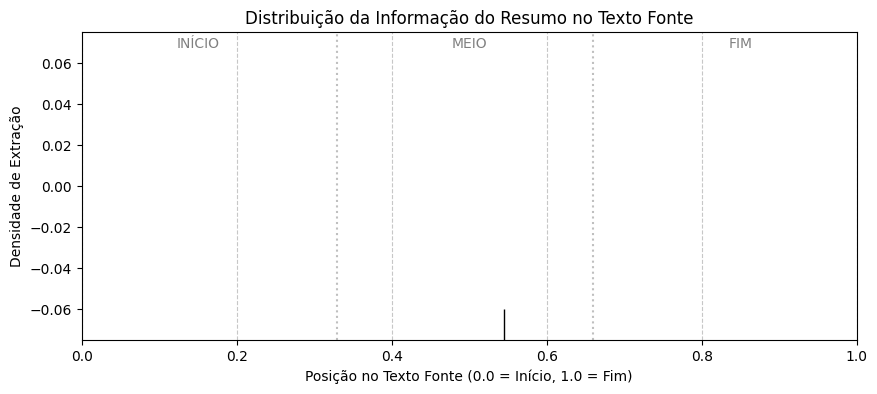


--- Analisando Resumo GERAL ---
Cobertura do Fonte: 18.18%


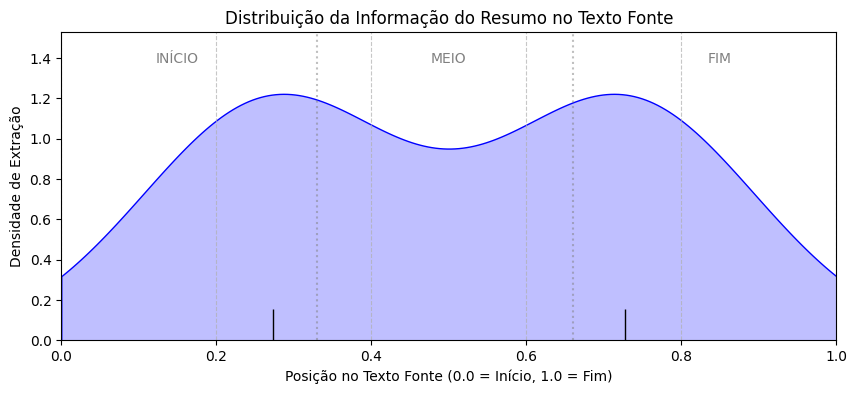

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Garantir que o tokenizador de sentenças esteja baixado
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

class SummaryCoverageAnalyzer:
    def __init__(self, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
        """
        Inicializa o modelo de embeddings.
        O modelo 'paraphrase-multilingual-MiniLM-L12-v2' é excelente para Português/Inglês
        e é rápido.
        """
        print(f"Carregando modelo {model_name}...")
        self.model = SentenceTransformer(model_name)

    def _split_sentences(self, text):
        """Quebra o texto em lista de sentenças."""
        return nltk.sent_tokenize(text)

    def analyze(self, source_text, summary_text, threshold=0.5):
        """
        Analisa a cobertura do resumo em relação ao texto fonte.

        Args:
            source_text (str): Texto original.
            summary_text (str): Resumo gerado.
            threshold (float): Limiar de similaridade para considerar que uma info foi coberta.
        """
        # 1. Segmentação
        source_sents = self._split_sentences(source_text)
        summary_sents = self._split_sentences(summary_text)

        if not source_sents or not summary_sents:
            return {"error": "Texto ou resumo vazios"}

        # 2. Embeddings
        # Calcula embeddings para todas as sentenças
        emb_source = self.model.encode(source_sents)
        emb_summary = self.model.encode(summary_sents)

        # 3. Matriz de Similaridade (Summary x Source)
        # Linhas = sentenças do resumo, Colunas = sentenças da fonte
        sim_matrix = cosine_similarity(emb_summary, emb_source)

        # 4. Análise Posicional e de Cobertura
        covered_indices = []
        max_scores = []

        # Para cada sentença do resumo, qual a melhor correspondência no texto fonte?
        for i, row_scores in enumerate(sim_matrix):
            best_match_idx = np.argmax(row_scores)
            best_score = row_scores[best_match_idx]

            # Guardamos o score para análise
            max_scores.append(best_score)

            # Se a similaridade for alta, consideramos que essa parte do texto foi "usada"
            if best_score >= threshold:
                covered_indices.append(best_match_idx)

        # Normalizar índices para escala 0.0 a 1.0 (Início -> Fim do texto)
        total_source_sents = len(source_sents)
        relative_positions = [idx / total_source_sents for idx in covered_indices]

        # Métrica: Porcentagem do texto fonte que foi "tocado" pelo resumo (aproximado)
        # Quantas sentenças únicas do fonte tiveram match com o resumo?
        unique_matches = len(set(covered_indices))
        source_coverage_score = unique_matches / total_source_sents

        return {
            "source_sentences_count": total_source_sents,
            "summary_sentences_count": len(summary_sents),
            "relative_positions": relative_positions, # Lista de posições (0.0 a 1.0)
            "source_coverage_score": source_coverage_score, # % do texto fonte coberto
            "avg_similarity": np.mean(max_scores)
        }

    def plot_coverage_distribution(self, relative_positions):
        """
        Gera um gráfico de densidade para mostrar de onde o resumo extraiu informações.
        """
        plt.figure(figsize=(10, 4))

        if not relative_positions:
            print("Nenhuma correspondência forte encontrada para plotar.")
            return

        # Plot KDE (Kernel Density Estimate) - mostra a "mancha de calor" da cobertura
        sns.kdeplot(relative_positions, clip=(0, 1), fill=True, color="blue", bw_adjust=0.6)

        # Plot Rugplot - mostra os "tracinhos" exatos de onde vieram as sentenças
        sns.rugplot(relative_positions, color="black", height=0.1)

        plt.title('Distribuição da Informação do Resumo no Texto Fonte')
        plt.xlabel('Posição no Texto Fonte (0.0 = Início, 1.0 = Fim)')
        plt.ylabel('Densidade de Extração')
        plt.xlim(0, 1)
        plt.grid(axis='x', linestyle='--', alpha=0.7)

        # Marcadores visuais
        plt.axvline(x=0.33, color='gray', linestyle=':', alpha=0.5)
        plt.axvline(x=0.66, color='gray', linestyle=':', alpha=0.5)
        plt.text(0.15, plt.gca().get_ylim()[1]*0.9, "INÍCIO", ha='center', color='gray')
        plt.text(0.5, plt.gca().get_ylim()[1]*0.9, "MEIO", ha='center', color='gray')
        plt.text(0.85, plt.gca().get_ylim()[1]*0.9, "FIM", ha='center', color='gray')

        plt.show()

# --- EXEMPLO DE USO ---

# Texto fonte fictício (sobre IA)
texto_fonte = """
A inteligência artificial começou como um campo acadêmico em 1956.
Durante anos, houve grande otimismo seguido por períodos de desilusão conhecidos como invernos da IA.
No entanto, o aumento da capacidade computacional permitiu novos avanços.
O aprendizado profundo (Deep Learning) revolucionou a área a partir de 2012.
Redes neurais começaram a superar humanos em reconhecimento de imagens.
Hoje, os Grandes Modelos de Linguagem (LLMs) são o foco principal.
O ChatGPT trouxe a IA generativa para o público geral.
Muitas empresas estão agora integrando IA em seus produtos.
O futuro da IA promete automação em larga escala, mas levanta questões éticas.
A regulação da IA é um tema quente em governos ao redor do mundo.
O final deste processo ainda é incerto, mas o impacto será global.
"""

# Resumo 1: Focado apenas no início (Histórico)
resumo_inicio = "A IA começou em 1956 e passou por invernos de desilusão antes do deep learning surgir."

# Resumo 2: Focado no final (Atualidade/Futuro)
resumo_fim = "Hoje os LLMs e o ChatGPT popularizaram a IA, levantando questões éticas e de regulação para o futuro."

# Resumo 3: Bem distribuído (Geral)
resumo_geral = "A IA evoluiu de um campo acadêmico para o Deep Learning. Hoje, com LLMs, impacta empresas e gera debates éticos sobre o futuro."

# Execução
analyzer = SummaryCoverageAnalyzer()

print("--- Analisando Resumo Focado no FIM ---")
resultados = analyzer.analyze(texto_fonte, resumo_fim)
print(f"Cobertura do Fonte: {resultados['source_coverage_score']:.2%}")
analyzer.plot_coverage_distribution(resultados['relative_positions'])

print("\n--- Analisando Resumo GERAL ---")
resultados = analyzer.analyze(texto_fonte, resumo_geral)
print(f"Cobertura do Fonte: {resultados['source_coverage_score']:.2%}")
analyzer.plot_coverage_distribution(resultados['relative_positions'])

Carregando modelo paraphrase-multilingual-MiniLM-L12-v2...
Cobertura Global do Texto Fonte: 28.57%

--- Distribuição da Informação ---
Região do Texto Fonte  Sentenças Extraídas Contribuição para o Resumo
    Início (0% - 33%)                    1                      50.0%
     Meio (33% - 66%)                    0                       0.0%
     Fim (66% - 100%)                    1                      50.0%
------------------------------


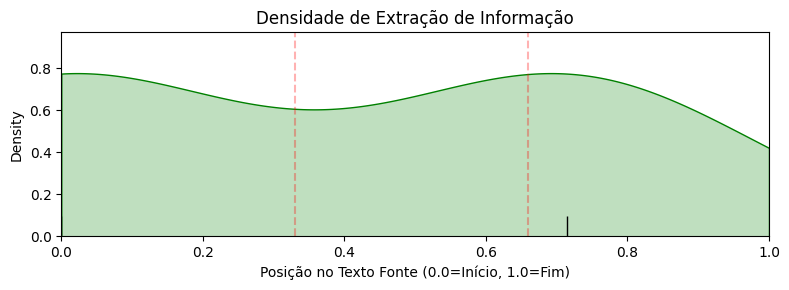

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Verifica tokenizador
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt')

class SummaryCoverageAnalyzer:
    def __init__(self, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
        print(f"Carregando modelo {model_name}...")
        self.model = SentenceTransformer(model_name)

    def _split_sentences(self, text):
        return nltk.sent_tokenize(text)

    def analyze(self, source_text, summary_text, threshold=0.5):
        """Executa a análise de cobertura e retorna métricas brutas."""
        source_sents = self._split_sentences(source_text)
        summary_sents = self._split_sentences(summary_text)

        if not source_sents or not summary_sents:
            return None

        # Embeddings e Similaridade
        emb_source = self.model.encode(source_sents)
        emb_summary = self.model.encode(summary_sents)
        sim_matrix = cosine_similarity(emb_summary, emb_source)

        covered_indices = []

        # Para cada sentença do resumo, acha a melhor correspondência no fonte
        for row_scores in sim_matrix:
            best_match_idx = np.argmax(row_scores)
            best_score = row_scores[best_match_idx]

            # Filtra apenas se a similaridade for relevante
            if best_score >= threshold:
                covered_indices.append(best_match_idx)

        total_source_sents = len(source_sents)
        # Calcula posições relativas (0.0 a 1.0)
        relative_positions = [idx / total_source_sents for idx in covered_indices]

        unique_matches = len(set(covered_indices))
        source_coverage_score = unique_matches / total_source_sents if total_source_sents > 0 else 0

        return {
            "relative_positions": relative_positions,
            "source_coverage_score": source_coverage_score
        }

    def print_position_table(self, relative_positions):
        """
        Gera e imprime uma tabela dividindo a origem das informações
        em Início, Meio e Fim.
        """
        if not relative_positions:
            print("Não há dados suficientes para gerar a tabela.")
            return

        # Contadores para os terços do texto
        counts = {
            "Início (0% - 33%)": 0,
            "Meio (33% - 66%)": 0,
            "Fim (66% - 100%)": 0
        }

        total_matches = len(relative_positions)

        for pos in relative_positions:
            if pos <= 0.33:
                counts["Início (0% - 33%)"] += 1
            elif pos <= 0.66:
                counts["Meio (33% - 66%)"] += 1
            else:
                counts["Fim (66% - 100%)"] += 1

        # Criação do DataFrame para exibição bonita
        df = pd.DataFrame([
            {
                "Região do Texto Fonte": k,
                "Sentenças Extraídas": v,
                "Contribuição para o Resumo": f"{(v/total_matches)*100:.1f}%"
            }
            for k, v in counts.items()
        ])

        print("\n--- Distribuição da Informação ---")
        print(df.to_string(index=False))
        print("-" * 30)

        # Retorna o dict caso queira usar os dados programaticamente
        return counts

    def plot_coverage(self, relative_positions):
        """Plota o gráfico de densidade."""
        if not relative_positions: return

        plt.figure(figsize=(8, 3))
        sns.kdeplot(relative_positions, clip=(0, 1), fill=True, color="green", bw_adjust=0.6)
        sns.rugplot(relative_positions, color="black", height=0.1)
        plt.title('Densidade de Extração de Informação')
        plt.xlabel('Posição no Texto Fonte (0.0=Início, 1.0=Fim)')
        plt.xlim(0, 1)

        # Linhas divisórias dos terços
        plt.axvline(x=0.33, color='red', linestyle='--', alpha=0.3)
        plt.axvline(x=0.66, color='red', linestyle='--', alpha=0.3)

        plt.tight_layout()
        plt.show()

# --- EXEMPLO DE USO ---

texto_fonte = """
[INTRODUÇÃO] A Revolução Industrial marcou um ponto de virada na história. Começou na Grã-Bretanha no século 18.
[DESENVOLVIMENTO] Máquinas a vapor mudaram a manufatura. A população migrou do campo para as cidades. As condições de trabalho eram difíceis.
[CONCLUSÃO] Hoje vemos os impactos ambientais daquele período. A sociedade mudou para sempre e a tecnologia continua avançando.
"""

# Exemplo: Resumo focado no início e no fim, ignorando o meio
resumo_teste = "A Revolução Industrial começou na Grã-Bretanha. Hoje vemos seus impactos ambientais e na sociedade."

analyzer = SummaryCoverageAnalyzer()
resultados = analyzer.analyze(texto_fonte, resumo_teste)

if resultados:
    print(f"Cobertura Global do Texto Fonte: {resultados['source_coverage_score']:.2%}")

    # 1. Gera a Tabela
    analyzer.print_position_table(resultados['relative_positions'])

    # 2. Gera o Gráfico
    analyzer.plot_coverage(resultados['relative_positions'])

In [ ]:
import numpy as np
import pandas as pd
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Configuração inicial do NLTK (silenciosa se já estiver baixado)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

class SummaryCoverageAnalyzer:
    def __init__(self, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
        # Modelo multilíngue leve e eficiente
        self.model = SentenceTransformer(model_name)

    def _split_sentences(self, text):
        return nltk.sent_tokenize(text)

    def analyze(self, source_text, summary_text, threshold=0.4):
        """
        Analisa cobertura e distribuição posicional.
        Args:
            threshold (float): Similaridade mínima (0.0 a 1.0) para considerar
                               que uma frase foi usada. 0.4 é um bom equilíbrio.
        """
        source_sents = self._split_sentences(source_text)
        summary_sents = self._split_sentences(summary_text)

        if not source_sents or not summary_sents:
            return None

        # Gerar Embeddings (Vetores Semânticos)
        emb_source = self.model.encode(source_sents)
        emb_summary = self.model.encode(summary_sents)

        # Matriz de Similaridade
        sim_matrix = cosine_similarity(emb_summary, emb_source)

        covered_indices = []

        # Para cada sentença do resumo, encontramos a melhor correspondência no fonte
        for row_scores in sim_matrix:
            best_match_idx = np.argmax(row_scores)
            score = row_scores[best_match_idx]

            # Se a similaridade for maior que o limiar, conta como "informação extraída"
            if score >= threshold:
                covered_indices.append(best_match_idx)

        # --- CÁLCULOS DE MÉTRICAS ---
        total_source = len(source_sents)
        unique_matches = len(set(covered_indices))
        extraction_ratio = unique_matches / total_source if total_source > 0 else 0

        # --- DISTRIBUIÇÃO POR SEGMENTOS ---
        segments = {'Início (0-33%)': 0, 'Meio (33-66%)': 0, 'Fim (66-100%)': 0}
        total_extracted = len(covered_indices)

        for idx in covered_indices:
            relative_pos = idx / total_source
            if relative_pos < 0.33:
                segments['Início (0-33%)'] += 1
            elif relative_pos < 0.66:
                segments['Meio (33-66%)'] += 1
            else:
                segments['Fim (66-100%)'] += 1

        # Calcula porcentagem de foco do resumo
        if total_extracted > 0:
            segments_pct = {k: v / total_extracted for k, v in segments.items()}
        else:
            segments_pct = {k: 0.0 for k, v in segments.items()}

        return {
            "source_count": total_source,
            "extracted_count": unique_matches,
            "extraction_ratio": extraction_ratio,
            "segments_pct": segments_pct
        }

# --- EXEMPLO DE USO ---

texto_fonte = """
A inteligência artificial começou como um campo acadêmico em 1956.
Durante anos, houve grande otimismo seguido por períodos de desilusão conhecidos como invernos da IA.
No entanto, o aumento da capacidade computacional permitiu novos avanços.
O aprendizado profundo (Deep Learning) revolucionou a área a partir de 2012.
Redes neurais começaram a superar humanos em reconhecimento de imagens.
Hoje, os Grandes Modelos de Linguagem (LLMs) são o foco principal.
O ChatGPT trouxe a IA generativa para o público geral.
Muitas empresas estão agora integrando IA em seus produtos.
O futuro da IA promete automação em larga escala, mas levanta questões éticas.
A regulação da IA é um tema quente em governos ao redor do mundo.
O final deste processo ainda é incerto, mas o impacto será global.
"""

resumo_exemplo = "A IA começou em 1956, passou por invernos e explodiu com Deep Learning. Hoje, LLMs levantam questões éticas para o futuro."

analyzer = SummaryCoverageAnalyzer()

# Execute a análise (threshold ajustado para 0.4 para ser mais flexível)
resultados = analyzer.analyze(texto_fonte, resumo_exemplo, threshold=0.4)

# Exibindo os Resultados
print(f"--- ANÁLISE DE COBERTURA (Threshold=0.4) ---\n")

print(f"Sentenças no Texto Fonte: {resultados['source_count']}")
print(f"Sentenças Únicas Extraídas: {resultados['extracted_count']}")
print(f"Taxa de Cobertura (Extraídas/Total): {resultados['extraction_ratio']:.1%}")

print("\n--- DISTRIBUIÇÃO DO FOCO (TABELA) ---")
df = pd.DataFrame([resultados['segments_pct']])

# CORREÇÃO AQUI: Usando .map() em vez de .applymap()
df = df.map(lambda x: f"{x:.1%}")

print(df.to_string(index=False))

--- ANÁLISE DE COBERTURA (Threshold=0.4) ---

Sentenças no Texto Fonte: 11
Sentenças Únicas Extraídas: 2
Taxa de Cobertura (Extraídas/Total): 18.2%

--- DISTRIBUIÇÃO DO FOCO (TABELA) ---
Início (0-33%) Meio (33-66%) Fim (66-100%)
         50.0%          0.0%         50.0%


In [ ]:
import numpy as np
import pandas as pd
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Configuração inicial do NLTK
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

class SummaryCoverageAnalyzer:
    def __init__(self, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
        self.model = SentenceTransformer(model_name)

    def _split_sentences(self, text):
        return nltk.sent_tokenize(text)

    def _get_segment(self, index, total):
        """Define a qual segmento (Início, Meio, Fim) um índice pertence."""
        relative_pos = index / total
        if relative_pos < 0.33:
            return 'Início (0-33%)'
        elif relative_pos < 0.66:
            return 'Meio (33-66%)'
        else:
            return 'Fim (66-100%)'

    def analyze(self, source_text, summary_text, threshold=0.4):
        source_sents = self._split_sentences(source_text)
        summary_sents = self._split_sentences(summary_text)

        if not source_sents or not summary_sents:
            return None

        # 1. Análise do Texto FONTE (Total Disponível)
        total_source = len(source_sents)
        source_dist = {'Início (0-33%)': 0, 'Meio (33-66%)': 0, 'Fim (66-100%)': 0}

        for i in range(total_source):
            seg = self._get_segment(i, total_source)
            source_dist[seg] += 1

        # 2. Embeddings e Similaridade
        emb_source = self.model.encode(source_sents)
        emb_summary = self.model.encode(summary_sents)
        sim_matrix = cosine_similarity(emb_summary, emb_source)

        covered_indices = []

        # 3. Identificar correspondências (Extração)
        for row_scores in sim_matrix:
            best_match_idx = np.argmax(row_scores)
            score = row_scores[best_match_idx]
            if score >= threshold:
                covered_indices.append(best_match_idx)

        unique_matches = len(set(covered_indices))
        extraction_ratio = unique_matches / total_source if total_source > 0 else 0

        # 4. Distribuição do que foi EXTRAÍDO
        extracted_dist = {'Início (0-33%)': 0, 'Meio (33-66%)': 0, 'Fim (66-100%)': 0}

        for idx in covered_indices:
            seg = self._get_segment(idx, total_source)
            extracted_dist[seg] += 1

        # 5. Cálculo de Densidade (% de cobertura por seção)
        density_dist = {}
        for k in source_dist:
            total_in_section = source_dist[k]
            extracted_in_section = extracted_dist[k]
            if total_in_section > 0:
                density_dist[k] = extracted_in_section / total_in_section
            else:
                density_dist[k] = 0.0

        return {
            "source_count": total_source,
            "extracted_count": unique_matches,
            "extraction_ratio": extraction_ratio,
            "source_dist": source_dist,       # Total disponível no fonte
            "extracted_dist": extracted_dist, # Total extraído pelo resumo
            "density_dist": density_dist      # % de cobertura da seção
        }

# --- EXEMPLO DE USO ---

texto_fonte = """
A inteligência artificial começou como um campo acadêmico em 1956.
Durante anos, houve grande otimismo seguido por períodos de desilusão conhecidos como invernos da IA.
No entanto, o aumento da capacidade computacional permitiu novos avanços.
O aprendizado profundo (Deep Learning) revolucionou a área a partir de 2012.
Redes neurais começaram a superar humanos em reconhecimento de imagens.
Hoje, os Grandes Modelos de Linguagem (LLMs) são o foco principal.
O ChatGPT trouxe a IA generativa para o público geral.
Muitas empresas estão agora integrando IA em seus produtos.
O futuro da IA promete automação em larga escala, mas levanta questões éticas.
A regulação da IA é um tema quente em governos ao redor do mundo.
O final deste processo ainda é incerto, mas o impacto será global.
"""

# Resumo que foca muito no início e no fim, mas ignora o meio
resumo_exemplo = "A IA começou em 1956 e teve invernos. No fim, a regulação é um tema global e incerto."

analyzer = SummaryCoverageAnalyzer()
resultados = analyzer.analyze(texto_fonte, resumo_exemplo, threshold=0.4)

# --- EXIBIÇÃO ---
print(f"--- ANÁLISE DE COBERTURA (Threshold=0.4) ---\n")
print(f"Total Sentenças Fonte: {resultados['source_count']}")
print(f"Total Extraídas: {resultados['extracted_count']}")
print(f"Cobertura Global: {resultados['extraction_ratio']:.1%}")

print("\n--- COMPARAÇÃO: FONTE vs RESUMO ---")

# Criando as linhas formatadas
row_total = {k: int(v) for k, v in resultados['source_dist'].items()}
row_used = {k: int(v) for k, v in resultados['extracted_dist'].items()}
row_density = {k: f"{v:.1%}" for k, v in resultados['density_dist'].items()}

# Criando DataFrame
df = pd.DataFrame([row_total, row_used, row_density])
df.index = ["Disponível (Fonte)", "Extraído (Resumo)", "Densidade da Seção"]

print(df.to_string())

--- ANÁLISE DE COBERTURA (Threshold=0.4) ---

Total Sentenças Fonte: 11
Total Extraídas: 2
Cobertura Global: 18.2%

--- COMPARAÇÃO: FONTE vs RESUMO ---
{'Início (0-33%)': 1, 'Meio (33-66%)': 0, 'Fim (66-100%)': 1}
                   Início (0-33%) Meio (33-66%) Fim (66-100%)
Disponível (Fonte)              4             4             3
Extraído (Resumo)               1             0             1
Densidade da Seção          25.0%          0.0%         33.3%


In [ ]:
import numpy as np
import pandas as pd
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Configuração inicial do NLTK
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

class SummaryCoverageAnalyzer:
    def __init__(self, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
        self.model = SentenceTransformer(model_name)

    def _split_sentences(self, text):
        return nltk.sent_tokenize(text)

    def _get_segment(self, index, total):
        """Define a qual segmento (Início, Meio, Fim) um índice pertence."""
        relative_pos = index / total
        if relative_pos < 0.33:
            return 'Início (0-33%)'
        elif relative_pos < 0.66:
            return 'Meio (33-66%)'
        else:
            return 'Fim (66-100%)'

    def analyze(self, source_text, summary_text, threshold=0.4):
        source_sents = self._split_sentences(source_text)
        summary_sents = self._split_sentences(summary_text)

        if not source_sents or not summary_sents:
            return None

        # 1. Embeddings e Similaridade
        emb_source = self.model.encode(source_sents)
        emb_summary = self.model.encode(summary_sents)
        sim_matrix = cosine_similarity(emb_summary, emb_source)

        # 2. Identificar quais índices do Fonte foram "cobertos"
        covered_indices = set() # Usar set para busca rápida

        for row_scores in sim_matrix:
            best_match_idx = np.argmax(row_scores)
            score = row_scores[best_match_idx]
            if score >= threshold:
                covered_indices.add(best_match_idx)

        # 3. Organizar os Textos por Posição e Status
        total_source = len(source_sents)

        # Estrutura para guardar o texto detalhado
        text_details = {
            'Início (0-33%)': [],
            'Meio (33-66%)': [],
            'Fim (66-100%)': []
        }

        # Contadores para a tabela numérica
        source_dist = {k: 0 for k in text_details.keys()}
        extracted_dist = {k: 0 for k in text_details.keys()}

        for i, sentence in enumerate(source_sents):
            segment = self._get_segment(i, total_source)

            # Verifica se essa sentença específica foi usada
            is_covered = i in covered_indices

            # Atualiza contadores
            source_dist[segment] += 1
            if is_covered:
                extracted_dist[segment] += 1

            # Salva o texto com um marcador visual
            marker = "[✔ USADA]" if is_covered else "[  ---  ]"
            text_details[segment].append(f"{marker} {sentence}")

        # 4. Cálculos Finais de Métricas
        unique_matches = len(covered_indices)
        extraction_ratio = unique_matches / total_source if total_source > 0 else 0

        # Densidade
        density_dist = {}
        for k in source_dist:
            if source_dist[k] > 0:
                density_dist[k] = extracted_dist[k] / source_dist[k]
            else:
                density_dist[k] = 0.0

        return {
            "source_count": total_source,
            "extracted_count": unique_matches,
            "extraction_ratio": extraction_ratio,
            "source_dist": source_dist,
            "extracted_dist": extracted_dist,
            "density_dist": density_dist,
            "text_details": text_details # <--- Novo campo com os textos
        }

# --- FUNÇÃO AUXILIAR DE VISUALIZAÇÃO ---
def print_detailed_sentences(details):
    print("\n" + "="*60)
    print(" DETALHAMENTO DAS SENTENÇAS POR POSIÇÃO")
    print("="*60)

    # Ordem correta de exibição
    order = ['Início (0-33%)', 'Meio (33-66%)', 'Fim (66-100%)']

    for segment in order:
        print(f"\n>>> {segment.upper()}")
        print("-" * 40)
        for sent in details[segment]:
            print(sent)

# --- EXEMPLO DE USO ---

texto_fonte = """
"""

# Resumo focado nas pontas, ignorando o meio
resumo_exemplo = """
"""

analyzer = SummaryCoverageAnalyzer()
resultados = analyzer.analyze(texto_fonte, resumo_exemplo, threshold=0.4)

# 1. Exibir Tabela Numérica
row_total = {k: int(v) for k, v in resultados['source_dist'].items()}
row_used = {k: int(v) for k, v in resultados['extracted_dist'].items()}
row_density = {k: f"{v:.1%}" for k, v in resultados['density_dist'].items()}

df = pd.DataFrame([row_total, row_used, row_density])
df.index = ["Disponível", "Extraído", "Densidade"]
print("--- ESTATÍSTICAS ---")
print(df.to_string())

# 2. Exibir Sentenças Detalhadas
print_detailed_sentences(resultados['text_details'])

--- ESTATÍSTICAS ---
           Início (0-33%) Meio (33-66%) Fim (66-100%)
Disponível              4             4             4
Extraído                2             3             1
Densidade           50.0%         75.0%         25.0%

 DETALHAMENTO DAS SENTENÇAS POR POSIÇÃO

>>> INÍCIO (0-33%)
----------------------------------------
[  ---  ] 
O cerrado, bioma que cobre cerca de 25% do território brasileiro, é uma savana tropical com uma biodiversidade extraordinária.
[  ---  ] Conhecido como a "caixa d'água do Brasil", abriga as nascentes de oito das doze principais bacias hidrográficas do país, desempenhando um papel crucial no abastecimento de recursos hídricos.
[✔ USADA] Sua paisagem é caracterizada por uma vegetação única, com árvores de troncos retorcidos, cascas grossas e raízes profundas, adaptadas a longos períodos de seca e solos ácidos.
[✔ USADA] Estima-se que existam mais de 12.000 espécies de plantas nativas, muitas delas endêmicas, além de uma fauna rica que inclui lo

In [ ]:
import numpy as np
import pandas as pd
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuração inicial do NLTK
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

class SummaryCoverageAnalyzer:
    def __init__(self, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
        """Inicializa o analisador com modelo de embeddings."""
        self.model = SentenceTransformer(model_name)

    def _split_sentences(self, text):
        """Divide texto em sentenças usando NLTK."""
        return nltk.sent_tokenize(text, language='portuguese')

    def _get_segment(self, index, total):
        """Define a qual segmento (Início, Meio, Fim) um índice pertence."""
        relative_pos = index / total
        if relative_pos < 0.33:
            return 'Início (0-33%)'
        elif relative_pos < 0.66:
            return 'Meio (33-66%)'
        else:
            return 'Fim (66-100%)'

    def find_optimal_threshold(self, sim_matrix, method='percentile', percentile=75):
        """
        Encontra threshold ótimo baseado na distribuição de similaridades.

        Args:
            sim_matrix: Matriz de similaridades
            method: 'percentile' ou 'elbow'
            percentile: Percentil a usar (se method='percentile')

        Returns:
            Threshold calculado
        """
        all_scores = sim_matrix.flatten()

        if method == 'percentile':
            return np.percentile(all_scores, percentile)
        elif method == 'elbow':
            # Método simplificado do cotovelo
            sorted_scores = np.sort(all_scores)
            diffs = np.diff(sorted_scores)
            elbow_idx = np.argmax(diffs) if len(diffs) > 0 else len(sorted_scores) // 2
            return sorted_scores[elbow_idx]
        else:
            return 0.4  # Default

    def _calculate_quality_metrics(self, sim_matrix, threshold):
        """
        Calcula métricas de qualidade: Precision, Recall, F1.

        Args:
            sim_matrix: Matriz de similaridade (summary x source)
            threshold: Limite de similaridade

        Returns:
            Dicionário com métricas
        """
        n_summary, n_source = sim_matrix.shape

        # Sentenças do resumo com pelo menos uma correspondência
        summary_has_match = np.any(sim_matrix >= threshold, axis=1)
        precision_matches = np.sum(summary_has_match)

        # Sentenças do fonte cobertas por pelo menos uma sentença do resumo
        source_covered = np.any(sim_matrix >= threshold, axis=0)
        recall_matches = np.sum(source_covered)

        # Cálculos
        precision = precision_matches / n_summary if n_summary > 0 else 0
        recall = recall_matches / n_source if n_source > 0 else 0

        # F1-Score
        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0

        # Densidade média de similaridade para sentenças cobertas
        if recall_matches > 0:
            avg_similarity = np.mean(sim_matrix[sim_matrix >= threshold])
        else:
            avg_similarity = 0

        return {
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'precision_matches': int(precision_matches),
            'recall_matches': int(recall_matches),
            'total_summary_sents': n_summary,
            'total_source_sents': n_source,
            'avg_similarity': avg_similarity
        }

    def analyze(self, source_text, summary_text, threshold=None, auto_threshold=True):
        """
        Analisa a cobertura do resumo em relação ao texto fonte.
        (Versão Normalizada por Tokens/Palavras)
        """
        # 1. Divisão em sentenças
        source_sents = self._split_sentences(source_text)
        summary_sents = self._split_sentences(summary_text)

        if not source_sents or not summary_sents:
            raise ValueError("Texto fonte ou resumo vazio")

        # --- [NOVO] LÓGICA DE SEGMENTAÇÃO POR TOKENS ---
        # Calculamos quantas palavras existem em cada sentença
        sent_lengths = [len(s.split()) for s in source_sents]
        total_tokens = sum(sent_lengths)

        # Mapa para dizer qual índice pertence a qual segmento (baseado em volume)
        segment_map = {}
        cumulative_tokens = 0

        for i, length in enumerate(sent_lengths):
            # O ponto médio da sentença define onde ela "vive" no texto
            # Ex: Se começa na palavra 10 e termina na 50, o ponto é 30.
            mid_point = cumulative_tokens + (length / 2)
            relative_pos = mid_point / total_tokens if total_tokens > 0 else 0

            if relative_pos < 0.33:
                segment_map[i] = 'Início (0-33%)'
            elif relative_pos < 0.66:
                segment_map[i] = 'Meio (33-66%)'
            else:
                segment_map[i] = 'Fim (66-100%)'

            cumulative_tokens += length
        # --- [FIM DA NOVA LÓGICA] ---


        # 2. Geração de embeddings (Inalterado)
        emb_source = self.model.encode(source_sents, show_progress_bar=False)
        emb_summary = self.model.encode(summary_sents, show_progress_bar=False)

        # 3. Matriz de similaridade (Inalterado)
        sim_matrix = cosine_similarity(emb_summary, emb_source)

        # 4. Determinar threshold (Inalterado)
        if threshold is None and auto_threshold:
            threshold = self.find_optimal_threshold(sim_matrix)
        elif threshold is None:
            threshold = 0.4

        # 5. Identificar sentenças cobertas (Inalterado)
        covered_indices = set()
        match_details = []

        for i, row_scores in enumerate(sim_matrix):
            matches = np.where(row_scores >= threshold)[0]
            for src_idx in matches:
                covered_indices.add(src_idx)
                match_details.append({
                    'summary_idx': i,
                    'source_idx': src_idx,
                    'similarity': row_scores[src_idx],
                    'summary_sent': summary_sents[i],
                    'source_sent': source_sents[src_idx]
                })

        # 6. Organizar por segmentos (MODIFICADO para usar o segment_map)
        text_details = {
            'Início (0-33%)': [],
            'Meio (33-66%)': [],
            'Fim (66-100%)': []
        }

        source_dist = {k: 0 for k in text_details.keys()}
        extracted_dist = {k: 0 for k in text_details.keys()}

        for i, sentence in enumerate(source_sents):
            # [ALTERAÇÃO AQUI] Usamos o mapa pré-calculado em vez de _get_segment
            segment = segment_map[i]

            source_dist[segment] += 1
            is_covered = i in covered_indices

            if is_covered:
                extracted_dist[segment] += 1

            marker = "[✓ USADA]" if is_covered else "[  ---  ]"
            text_details[segment].append(f"{marker} {sentence}")

        # 7. Cálculo de métricas (Inalterado)
        unique_matches = len(covered_indices)
        extraction_ratio = unique_matches / len(source_sents) if len(source_sents) > 0 else 0

        density_dist = {}
        for k in source_dist:
            if source_dist[k] > 0:
                density_dist[k] = extracted_dist[k] / source_dist[k]
            else:
                density_dist[k] = 0.0

        # 8. Métricas de qualidade (Inalterado)
        quality_metrics = self._calculate_quality_metrics(sim_matrix, threshold)

        # 9. Análise de similaridade por segmento (MODIFICADO para usar segment_map)
        segment_similarities = {k: [] for k in text_details.keys()}
        for match in match_details:
            src_idx = match['source_idx']
            # [ALTERAÇÃO AQUI] Usamos o mapa pré-calculado
            segment = segment_map[src_idx]
            segment_similarities[segment].append(match['similarity'])

        avg_segment_similarity = {}
        for segment, similarities in segment_similarities.items():
            avg_segment_similarity[segment] = np.mean(similarities) if similarities else 0

        return {
            'source_count': len(source_sents),
            'summary_count': len(summary_sents),
            'extracted_count': unique_matches,
            'extraction_ratio': extraction_ratio,
            'source_dist': source_dist,
            'extracted_dist': extracted_dist,
            'density_dist': density_dist,
            'segment_similarities': avg_segment_similarity,
            'quality_metrics': quality_metrics,
            'match_details': match_details,
            'similarity_matrix': sim_matrix,
            'threshold_used': threshold,
            'text_details': text_details,
            'source_sentences': source_sents,
            'summary_sentences': summary_sents
        }

# --- FUNÇÕES DE VISUALIZAÇÃO ---
def print_detailed_sentences(details):
    """Exibe sentenças detalhadas por posição."""
    print("\n" + "="*60)
    print(" DETALHAMENTO DAS SENTENÇAS POR POSIÇÃO")
    print("="*60)

    order = ['Início (0-33%)', 'Meio (33-66%)', 'Fim (66-100%)']

    for segment in order:
        print(f"\n>>> {segment.upper()}")
        print("-" * 40)
        if details[segment]:
            for sent in details[segment]:
                print(sent)
        else:
            print("[Nenhuma sentença nesta seção]")

def print_quality_metrics(metrics):
    """Exibe métricas de qualidade do resumo."""
    print("\n" + "="*60)
    print(" MÉTRICAS DE QUALIDADE DO RESUMO")
    print("="*60)

    q = metrics['quality_metrics']

    print(f"\n1. COBERTURA (Recall):")
    print(f"   • Sentenças cobertas: {q['recall_matches']}/{q['total_source_sents']}")
    print(f"   • Porcentagem: {q['recall']:.1%}")

    print(f"\n2. RELEVÂNCIA (Precision):")
    print(f"   • Sentenças relevantes: {q['precision_matches']}/{q['total_summary_sents']}")
    print(f"   • Porcentagem: {q['precision']:.1%}")

    print(f"\n3. EQUILÍBRIO (F1-Score):")
    print(f"   • Score: {q['f1_score']:.3f}")
    print(f"   • Interpretação: ", end="")
    if q['f1_score'] >= 0.7:
        print("Excelente ✓")
    elif q['f1_score'] >= 0.5:
        print("Bom")
    elif q['f1_score'] >= 0.3:
        print("Regular")
    else:
        print("Baixa qualidade")

    print(f"\n4. SIMILARIDADE MÉDIA:")
    print(f"   • Valor: {q['avg_similarity']:.3f}")
    print(f"   • Threshold usado: {metrics['threshold_used']:.3f}")

def print_matching_details(results, max_matches=5):
    """Exibe detalhes das correspondências encontradas."""
    print("\n" + "="*60)
    print(" DETALHES DAS CORRESPONDÊNCIAS (TOP 5)")
    print("="*60)

    if not results['match_details']:
        print("\nNenhuma correspondência encontrada acima do threshold.")
        return

    # Ordenar por similaridade (maior primeiro)
    sorted_matches = sorted(results['match_details'],
                           key=lambda x: x['similarity'],
                           reverse=True)

    for i, match in enumerate(sorted_matches[:max_matches]):
        print(f"\n[{i+1}] Similaridade: {match['similarity']:.3f}")
        print(f"   Resumo: \"{match['summary_sent'][:80]}...\"")
        print(f"   Fonte:  \"{match['source_sent'][:80]}...\"")

def print_segment_analysis(results):
    """Exibe análise detalhada por segmento."""
    print("\n" + "="*60)
    print(" ANÁLISE POR SEGMENTO DO TEXTO")
    print("="*60)

    # Criar DataFrame
    segments = ['Início (0-33%)', 'Meio (33-66%)', 'Fim (66-100%)']

    data = {
        'Segmento': segments,
        'Disponível': [results['source_dist'][s] for s in segments],
        'Extraído': [results['extracted_dist'][s] for s in segments],
        'Densidade': [f"{results['density_dist'][s]:.1%}" for s in segments],
        'Sim. Média': [f"{results['segment_similarities'][s]:.3f}"
                      if results['segment_similarities'][s] > 0 else "0.000"
                      for s in segments]
    }

    df = pd.DataFrame(data).set_index('Segmento')

    print("\nTabela de Distribuição:")
    print(df.to_string())

    # Análise interpretativa
    print("\n📊 INTERPRETAÇÃO:")

    densities = results['density_dist']
    if densities['Meio (33-66%)'] > densities['Início (0-33%)'] and \
       densities['Meio (33-66%)'] > densities['Fim (66-100%)']:
        print("• O resumo foca principalmente no MEIO do texto ✓")
    elif densities['Início (0-33%)'] > densities['Meio (33-66%)']:
        print("• O resumo tende a cobrir mais o INÍCIO do texto")
    elif densities['Fim (66-100%)'] > densities['Meio (33-66%)']:
        print("• O resumo tende a cobrir mais o FIM do texto")
    else:
        print("• O resumo tem cobertura equilibrada entre segmentos")

# --- FUNÇÃO PRINCIPAL DE ANÁLISE ---
def analyze_summary_coverage(source_text, summary_text, threshold=None, verbose=True):
    """
    Função principal para analisar cobertura de resumo.

    Args:
        source_text: Texto fonte completo
        summary_text: Texto resumido
        threshold: Limite de similaridade (None para automático)
        verbose: Se True, exibe relatório detalhado

    Returns:
        Dicionário com resultados completos
    """
    analyzer = SummaryCoverageAnalyzer()

    if verbose:
        print("🔍 ANALISANDO COBERTURA DO RESUMO")
        print("="*60)

    # Executar análise
    results = analyzer.analyze(source_text, summary_text, threshold)

    if verbose:
        # 1. Métricas de qualidade
        print_quality_metrics(results)

        # 2. Análise por segmento
        print_segment_analysis(results)

        # 3. Tabela resumo
        print("\n" + "="*60)
        print(" RESUMO ESTATÍSTICO")
        print("="*60)

        summary_stats = pd.DataFrame({
            'Métrica': [
                'Sentenças no Fonte',
                'Sentenças no Resumo',
                'Sentenças Cobertas',
                'Taxa de Cobertura',
                'Threshold Usado'
            ],
            'Valor': [
                results['source_count'],
                results['summary_count'],
                results['extracted_count'],
                f"{results['extraction_ratio']:.1%}",
                f"{results['threshold_used']:.3f}"
            ]
        })
        print(summary_stats.to_string(index=False))

        # 4. Detalhes das correspondências (opcional)
        if input("\nMostrar detalhes das correspondências? (s/n): ").lower() == 's':
            print_matching_details(results)

        # 5. Sentenças detalhadas (opcional)
        if input("\nMostrar sentenças detalhadas por posição? (s/n): ").lower() == 's':
            print_detailed_sentences(results['text_details'])

    return results

# --- EXEMPLO DE USO COM OS TEXTOS ANTERIORES ---
if __name__ == "__main__":
    # Texto fonte (exemplo sobre o Cerrado)
    texto_fonte = """
    O cerrado, bioma que cobre cerca de 25% do território brasileiro, é uma savana tropical com uma biodiversidade extraordinária. Conhecido como a "caixa d'água do Brasil", abriga as nascentes de oito das doze principais bacias hidrográficas do país, desempenhando um papel crucial no abastecimento de recursos hídricos. Sua paisagem é caracterizada por uma vegetação única, com árvores de troncos retorcidos, cascas grossas e raízes profundas, adaptadas a longos períodos de seca e solos ácidos. Estima-se que existam mais de 12.000 espécies de plantas nativas, muitas delas endêmicas, além de uma fauna rica que inclui lobos-guará, tamanduás-bandeira e inúmeras espécies de aves e répteis. Apesar de sua imensa importância ecológica, o cerrado é um dos biomas mais ameaçados do planeta. Nas últimas décadas, a expansão acelerada da agropecuária, especialmente para a produção de soja e a criação de gado, tem sido a principal responsável pelo seu desmatamento. O processo de conversão do solo para pastagens e lavouras libera grandes quantidades de carbono estocado na vegetação e no solo, contribuindo significativamente para as emissões de gases de efeito estufa do Brasil. Além disso, o uso intensivo de agrotóxicos e fertilizantes contamina os lençóis freáticos e os rios que nascem na região, comprometendo a qualidade da água para milhões de pessoas. A fragmentação do habitat, causada pelo avanço das fronteiras agrícolas, isola populações de animais e plantas, reduzindo sua variabilidade genética e aumentando o risco de extinção. Apesar da existência de leis e áreas de conservação, a fiscalização é insuficiente e o ritmo de degradação permanece alarmante. A preservação do cerrado não é apenas uma questão ambiental, mas também econômica e social, pois milhões de pessoas, incluindo comunidades tradicionais e povos indígenas, dependem diretamente de seus recursos para sobreviver. A adoção de práticas agrícolas sustentáveis, o fortalecimento da proteção legal e o investimento em pesquisa para valorizar os produtos do bioma são caminhos essenciais para reverter esse cenário de devastação.
    """

    # Resumo focado no meio do texto (conforme solicitado anteriormente)
    resumo_exemplo = """
    O cerrado possui uma vegetação adaptada a longos períodos de seca, com árvores de troncos retorcidos e raízes profundas. Estima-se que existam mais de 12.000 espécies de plantas nativas nesse bioma, além de uma fauna rica que inclui lobos-guará e tamanduás-bandeira. Contudo, a expansão acelerada da agropecuária para a produção de soja e a criação de gado tem sido a principal responsável pelo seu desmatamento nas últimas décadas. Esse processo de conversão do solo libera grandes quantidades de carbono estocado, contribuindo para as emissões de gases de efeito estufa. Além disso, o uso intensivo de agrotóxicos e fertilizantes na região contamina os lençóis freáticos e os rios, comprometendo a qualidade da água. A fragmentação do habitat causada pela agricultura também isola populações de animais e plantas, aumentando seu risco de extinção.


    """

    print("📝 EXEMPLO DE ANÁLISE: RESUMO DO CERRADO")
    print("="*60)

    # Executar análise
    resultados = analyze_summary_coverage(
        source_text=texto_fonte,
        summary_text=resumo_exemplo,
        threshold=None,  # Usar threshold automático
        verbose=True
    )

    # Exemplo de acesso programático aos resultados
    print("\n" + "="*60)
    print(" ACESSO PROGRAMÁTICO AOS RESULTADOS")
    print("="*60)
    print(f"F1-Score: {resultados['quality_metrics']['f1_score']:.3f}")
    print(f"Densidade no Meio: {resultados['density_dist']['Meio (33-66%)']:.1%}")
    print(f"Número de correspondências: {len(resultados['match_details'])}")

📝 EXEMPLO DE ANÁLISE: RESUMO DO CERRADO
🔍 ANALISANDO COBERTURA DO RESUMO

 MÉTRICAS DE QUALIDADE DO RESUMO

1. COBERTURA (Recall):
   • Sentenças cobertas: 11/12
   • Porcentagem: 91.7%

2. RELEVÂNCIA (Precision):
   • Sentenças relevantes: 6/6
   • Porcentagem: 100.0%

3. EQUILÍBRIO (F1-Score):
   • Score: 0.957
   • Interpretação: Excelente ✓

4. SIMILARIDADE MÉDIA:
   • Valor: 0.633
   • Threshold usado: 0.444

 ANÁLISE POR SEGMENTO DO TEXTO

Tabela de Distribuição:
                Disponível  Extraído Densidade Sim. Média
Segmento                                                 
Início (0-33%)           4         3     75.0%      0.759
Meio (33-66%)            4         4    100.0%      0.634
Fim (66-100%)            4         4    100.0%      0.568

📊 INTERPRETAÇÃO:
• O resumo tem cobertura equilibrada entre segmentos

 RESUMO ESTATÍSTICO
            Métrica Valor
 Sentenças no Fonte    12
Sentenças no Resumo     6
 Sentenças Cobertas    11
  Taxa de Cobertura 91.7%
    Threshold 

### Teste com o BertScrore e Cosseno de similaridade

In [ ]:
!pip install transformers
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip install sentence-transformers bert-score moverscore

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for moverscore: filename=moverscore-1.0.3-py3-none-any.whl size=7950 sha256=0680b7ffd05da8d4859643af0572aeaecbf9605e0781cd2b78a1556acff24837
  Stored in directory: /root/.cache/pip/wheels/76/20/33/fffbeb74a615f13ae51c974da807383935518b3ec821609c02
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=4bef236d15dfa0c7ebcc984436c3b15fcdcc9214f206cb4a7ef64aa9ca1bb666
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built moverscore typing


In [ ]:
!pip install scikit-learn

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, util
from bert_score import score as bertscore_score
#from moverscore import get_idf_dict, word_mover_score

from transformers import BertTokenizer, BertModel
from bert_score import BERTScorer


# ---------------------------------------------------
# Função 1: Word Embeddings + Cosseno
# ---------------------------------------------------

def similarity_word_embedding(text1, text2, model_name="all-MiniLM-L6-v2"):
    model = SentenceTransformer(model_name)

    # Encode as embeddings
    emb1 = model.encode(text1, convert_to_tensor=True)
    emb2 = model.encode(text2, convert_to_tensor=True)

    # Cosseno de similaridade
    sim = cosine_similarity(
        emb1.unsqueeze(0).cpu().numpy(),
        emb2.unsqueeze(0).cpu().numpy()
    )[0][0]

    return sim

# ---------------------------------------------------
# Função 2: BERTScore
# ---------------------------------------------------

def similarity_bertscore(text1, text2, lang="en"):

    # Retorna scores P (precisão), R (recall), F1 (métrica combinada)
    P, R, F1 = bertscore_score(
        [text1], [text2],
        lang=lang,
        rescale_with_baseline=True,
        #model_type='bert-base-uncased'
        model_type="microsoft/deberta-large-mnli",
    )
    # F1 é geralmente a métrica mais estável
    return float(F1.mean().item())

# ---------------------------------------------------
# Função 3: MoverScore
# ---------------------------------------------------

"""def similarity_moverscore(text1, text2):
    # MoverScore precisa de listas de textos
    refs = [text1]
    hyps = [text2]

    # Gera dicionários IDF
    idf_ref = get_idf_dict(refs)
    idf_hyp = get_idf_dict(hyps)

    # Calcula MoverScore
    scores = word_mover_score(
        refs, hyps,
        idf_ref, idf_hyp,
        stop_words=[],
        n_gram=1,
        remove_subwords=True
    )
    return float(np.mean(scores))"""

# ---------------------------------------------------
# Teste com exemplos
# ---------------------------------------------------

if __name__ == "__main__":
    text_a = "The cat sat on the mat and looked at the dog playfully."
    text_b = "A cat was sitting on the rug watching the dog play."

    print("Teste 0.70")
    print("Word Embeddings + Cosine:", similarity_word_embedding(text_a, text_b))
    print("BERTScore F1:", similarity_bertscore(text_a, text_b))
    #print("MoverScore:", similarity_moverscore(text_a, text_b))

    text_a = "Artificial intelligence is widely used in NLP."
    text_b = "AI is extensively applied to natural language processing tasks."

    print("\nTeste 0.85")
    print("Word Embeddings + Cosine:", similarity_word_embedding(text_a, text_b))
    print("BERTScore F1:", similarity_bertscore(text_a, text_b))
    model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
    score = util.cos_sim(text_a, text_b)


    text_a = "Artificial intelligence is widely used in NLP."
    text_b = "Deep learning improves image classification accuracy."

    print("\nTeste 0.40")
    print("Word Embeddings + Cosine:", similarity_word_embedding(text_a, text_b))
    print("BERTScore F1:", similarity_bertscore(text_a, text_b))

    model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
    score = util.cos_sim(text_a, text_b)



Teste 0.70
Word Embeddings + Cosine: 0.69478893


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

BERTScore F1: 0.7178292274475098

Teste 0.85
Word Embeddings + Cosine: 0.7533622
BERTScore F1: 0.5088521838188171

Teste 0.40
Word Embeddings + Cosine: 0.20213328
BERTScore F1: 0.2659986913204193
